In [5]:
import numpy as np 
import pandas as pd 
from glob import glob
from tqdm import tqdm
from pybedtools import BedTool
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from datasketch import MinHash
import edlib
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import gzip 
import re
from matplotlib.patches import Rectangle
from collections import defaultdict


In [50]:
def find_substring_indices_regex(text: str, substring: str, invert: bool = False):
    """
    Find all starting indices in string where a pattern occurs. Looking for CCCTAA in the telo
    Returns: np array of starting indices.
    """
    
    sub_len = len(substring)
    substring = substring.lower()
    text = text.lower()
    if not invert:

        pattern = re.escape(substring)
        flags = re.IGNORECASE
    else:

        pattern = r"(?i)(?=(?!" + re.escape(substring) + r").{" + f"{sub_len}" + r"})"
        flags = 0 
    
    matches = [match.start() for match in re.finditer(pattern, text, flags)]
    
    return np.array(matches)

def plot_telomere_molecules_with_motifs(
    tsv: pd.DataFrame,
    max_size: int = 15_000,
    with_m6a: bool = True,
    pdf_path: str = None,
    ax: plt.Axes = None,
    title_prefix: str = "",
    ylim: int = 50
):
    """
    For each telomere end, plot individual molecules aligned at the subtelo/telo bundary
    Color CCCTAA in blue, and all other 6mers in red
     """
    grouped = (
        tsv.assign(span=tsv.centered_query_end)
           .sort_values("span", ascending=True)
           .groupby(["chrom", "centering_position"])
    )

    pdf = PdfPages(pdf_path) if pdf_path else None
    plots = []

    for (chrom, center_pos), group in grouped:
        print(f"Processing {chrom}:{center_pos} with {len(group)} reads")
        fig, ax = plt.subplots(figsize=(10, 6))

        for i, row in enumerate(group.itertuples()):
            seq = row.query_sequence
            qs = int(row.centered_query_end)

            if not isinstance(seq, str) or qs < 1:
                continue

            subseq = seq[-qs:]
            plus_idx = find_substring_indices_regex(subseq, "ccctaa", invert=False)
            minus_idx = find_substring_indices_regex(subseq, "ttaggg", invert=False)
            true_idx = plus_idx if len(plus_idx) > len(minus_idx) else minus_idx
            
            # fast way to id non-canon base sites
            # with identity of proper motifs, we can look for regions where the distance between 
            # motifs
            # the distance between motifs must be 6
            # for example: if substitution in canonical 6mer then you won't id at that site, and the distance between the start of the previous 6mer 
            # and the start of the next 6mer is 12 
            # if deletion with size not multiple of 6, then distance between start of motif i-1 and i+1 will be > 0 
            # if deletion is multiple of 6 then you have canonical stretch
            # same logic can apply to insertions
            
            diffs = np.diff(true_idx)
            improper_motif_start_idx = true_idx[:-1][diffs > 6] + 6
            improper_motif_size = diffs[diffs > 6] - 6
            size_idx = improper_motif_size > 0

            # Canonical background
            ax.add_patch(Rectangle((0, i - 0.4), len(subseq) - 6, 0.8, color='deepskyblue', alpha=1, linewidth=0))

            # Variant motifs
            for start, length in zip(improper_motif_start_idx[size_idx], improper_motif_size[size_idx]):
                ax.add_patch(Rectangle((int(start), i - 0.4), int(length), 0.8, color='red', alpha=1, linewidth=0))

        ax.set_xlim(0, max_size)
        ax.set_ylim(-2, ylim)
        ax.set_title(f"{title_prefix}{chrom}:{center_pos} with {len(group)} reads")
        ax.set_xlabel("Position (bp)")
        ax.set_ylabel("Molecule index")
#         plt.show()

        if pdf:
            pdf.savefig(fig, dpi=650)
            plt.show()
            plt.close(fig)
        elif not external_ax:

            plots.append((fig, ax, f"{chrom}:{center_pos}"))

    if pdf:
        pdf.close()

    return plots


In [18]:
labels = [
          'T-ONT-R10','BL-ONT-R10',
          'T-PB', 'BL-PB']
keys = [
 'COLO829-T-PassageB_UL-ONT-R10',
 'COLO829-BL_UL-ONT-R10',
 'COLO829-T_pb',
 'COLO829-BL_pb']  


col_names = ['chrom',
         'centering_position',
         'strand',
         'subset_sequence',
         'reference_start',
         'reference_end',
         'query_name',
         'RG',
         'HP',
         'centered_query_start',
         'centered_query_end',
         'query_length',
         'query_sequence']


all_centered_tsv = {}

for file in glob("*clean.gz"):
    
    sample_tsv = pd.read_csv(file,sep="\t",index_col=False,header=None,names=col_names,skiprows=1)
        
    sample_id = file.split('.')[0]
    if sample_id  in keys:
        all_centered_tsv[sample_id] = sample_tsv
    
    

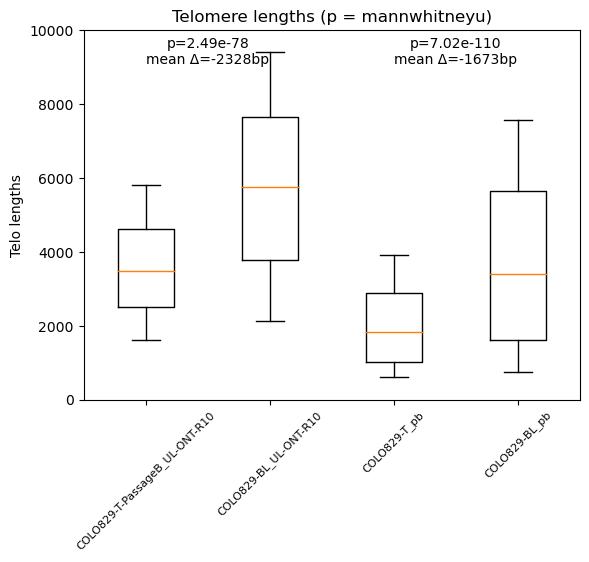

In [25]:
all_lens = []
labels = []
for sample in keys:
    tsv = all_centered_tsv[sample]
    all_lens.append(np.array(tsv['centered_query_end']))
    labels.append(sample)
plt.boxplot(all_lens,sym="",whis=(10,90))
plt.xticks(range(1,5), labels, fontsize=8,rotation=45)
plt.ylim(0,10_000)
plt.ylabel('Telo lengths')
plt.title('Telomere lengths (p = mannwhitneyu)')
pairs = [(1,2), (3,4)]

y_max = 10_000
h = y_max * 0.005  
for i, (a, b) in enumerate(pairs):
    data1, data2 = all_lens[a-1], all_lens[b-1]
    stat, pval = mannwhitneyu(data1, data2)
    delta = np.mean(data1) - np.mean(data2)
    y = y_max + (i+1)*h
    plt.text((a+b)/2, 9_000, f"p={pval:.2e}\nmean Δ={int(np.around(delta,0))}bp", ha='center', va='bottom')
plt.show()

In [55]:
def _plot_one_sample(
    tsv: pd.DataFrame,
    chrom: str,
    center_pos: int,
    ax: plt.Axes,
    max_size: int = 15_000,
    with_m6a: bool = True,
    title_prefix: str = "",
    ylim: int = 50,
    shade_alpha: float = 0.08,
):

    group = (
        tsv.loc[(tsv["chrom"] == chrom) & (tsv["centering_position"] == int(center_pos))]
           .assign(span=lambda df: df["centered_query_end"])
           .sort_values("span", ascending=True)
    )
   
    n_reads = len(group)
    if n_reads == 0:
        ax.set_xlim(0, max_size)
        ax.set_ylim(-2, ylim)
        ax.set_title(f"{title_prefix}{chrom}:{center_pos} (no reads)")
        ax.set_xlabel("Position (bp)")
        ax.set_ylabel("Molecule index")
        return

    for i, row in enumerate(group.itertuples(index=False)):
        seq = getattr(row, "query_sequence", None)
        qs = int(getattr(row, "centered_query_end", 0))

        if not isinstance(seq, str) or qs < 1:
            continue

        subseq = seq[-qs:]
        
        # Find telomeric 6mer direction by which motif is more
        plus_idx  = find_substring_indices_regex(subseq, "ccctaa", invert=False)
        minus_idx = find_substring_indices_regex(subseq, "ttaggg", invert=False)
        true_idx = plus_idx if len(plus_idx) >= len(minus_idx) else minus_idx

        diffs = np.diff(true_idx) if len(true_idx) > 1 else np.array([], dtype=int)
        improper_mask = diffs > 6
        improper_motif_start_idx = (true_idx[:-1][improper_mask] + 6) if improper_mask.any() else np.array([], dtype=int)
        improper_motif_size = diffs[improper_mask] - 6 if improper_mask.any() else np.array([], dtype=int)
        size_idx = improper_motif_size > 0

        # draw a blue strip for the telomeric portion
        if len(subseq) >= 6:
            ax.add_patch(Rectangle((0, i - 0.4), len(subseq) - 6, 0.8,
                                   color='deepskyblue', alpha=1.0, linewidth=0))

        # overlay in red where spacing departs from 6 ( not canon motif )
        for start, length in zip(improper_motif_start_idx[size_idx], improper_motif_size[size_idx]):
            ax.add_patch(Rectangle((int(start), i - 0.4), int(length), 0.8,
                                   color='red', alpha=1.0, linewidth=0))

        # add m6a potentially
        if with_m6a and "centered_m6a_positions" in group.columns:
            m6a_str = getattr(row, "centered_m6a_positions", "")
            if isinstance(m6a_str, str) and m6a_str.strip():
                try:
                    m6a_pos = np.array([int(x) for x in m6a_str.split(",") if x.strip() != "" and x != "None"], dtype=int)
                    # draw tiny vertical ticks for m6A
                    for x in m6a_pos[(m6a_pos >= 0) & (m6a_pos <= max_size)]:
                        ax.plot([x, x], [i - 0.35, i + 0.35], linewidth=0.6)
                except Exception:
                    pass  # silently ignore parsing issues

    ax.set_xlim(0, max_size)
    ax.set_ylim(-2, max(ylim, n_reads + 2))
    ax.set_title(f"{title_prefix}{chrom}:{center_pos} (n={n_reads})")
    ax.set_xlabel("Position (bp)")
    ax.set_ylabel("Molecule index")
    ax.set_xticks(range(0,max_size,2_000),range(0,max_size,2_000))


def plot_two_samples_telomeres(
    tsv1: pd.DataFrame,
    tsv2: pd.DataFrame,
    loci: list[tuple[str, int]],
    max_size: int = 15_000,
    with_m6a: bool = True,
    pdf_path: str | None = None,
    title_prefix_1: str = "Sample 1 — ",
    title_prefix_2: str = "Sample 2 — ",
    ylim: int = 50,
    shade_coords_1: tuple | dict | None = None,
    shade_coords_2: tuple | dict | None = None,
    figsize=(12, 8),
    hspace=0.35,
):
    """
    input: 
    tsv1, tsv2 : TSV dfs for the two samples. Must contain : 
        ['chrom', 'centering_position', 'centered_query_end', 'query_sequence']
    loci : list of (chrom, centering_position)
    max_size : i X-axis max (bp)
    with_m6a :  If True, try to plot m6A ticks from 'centered_m6a_positions'
    pdf_path : If provided, save a page per locus into this PDF
    title_prefix_1, title_prefix_2 :  Title prefixes for the two panels
    hspace : Vertical spacing between subplots

    returns :list of (fig, (ax1, ax2), "chrom:center")
    """
    pdf = PdfPages(pdf_path) if pdf_path else None
    plots = []

    for chrom, center_pos in loci:
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=figsize, sharex=True)
        fig.subplots_adjust(hspace=hspace)

        _plot_one_sample(
            tsv=tsv1,
            chrom=chrom,
            center_pos=center_pos,
            ax=ax1,
            max_size=max_size,
            with_m6a=with_m6a,
            title_prefix=title_prefix_1,
            ylim=ylim,
        )
        _plot_one_sample(
            tsv=tsv2,
            chrom=chrom,
            center_pos=center_pos,
            ax=ax2,
            max_size=max_size,
            with_m6a=with_m6a,
            title_prefix=title_prefix_2,
            ylim=ylim,
        )

        # Align x across both
        ax1.set_xlim(0, max_size)
        ax2.set_xlim(0, max_size)

        # Cleaner shared x label
        ax2.set_xlabel("Position (bp)")

        # Save / collect
        print(f"{chrom}:{center_pos}")
        if pdf:
            pdf.savefig(fig, dpi=650)
            plt.show()
            plt.close(fig)

        else:
            
            plots.append((fig, (ax1, ax2), f"{chrom}:{center_pos}"))
            plt.show()

    if pdf:
        pdf.close()

    return plots


In [57]:
# check for duplicates
from collections import defaultdict

def read_fasta(path):
    """
    Stream fasta entries as (name, seq) and works with fa,fasta and if gzip
    """
    opener = gzip.open if str(path).endswith(".gz") else open
    name, seq_chunks = None, []
    with opener(path, "rt") as fh:
        for line in fh:
            if not line:
                continue
            if line.startswith(">"):
                if name is not None:
                    yield name, "".join(seq_chunks)
                name = line[1:].strip().split()[0]
                seq_chunks = []
            else:
                seq_chunks.append(line.strip())
        if name is not None:
            yield name, "".join(seq_chunks)
            
def report_duplicate_sequence_labels(
    fasta_path,
    ignore_case=True,
    drop_whitespace=True,
    drop_gaps=False,
    collapse_revcomp=False,
):
    """
    inputs :
    fasta_path  Path to FASTA (works with  read_fasta).
    ignore_case  Upper-case sequences before comparing.
    drop_whitespace Remove all whitespace/newlines inside sequences before comparing.
    drop_gaps  Remove '-' gap characters before comparing.
    collapse_revcomp   Treat reverse-complements as identical (DNA only).
    
    returns : dict where key is sequence and value is the telo ends with it 
    """

    def canon(seq: str):
        s = seq
        if drop_whitespace:
            s = "".join(s.split())
        if drop_gaps:
            s = s.replace("-", "")
        if ignore_case:
            s = s.upper()
        return s

    def revcomp(s: str):
        tbl = str.maketrans("ACGTNacgtn", "TGCANtgcan")
        return s.translate(tbl)[::-1]

    seq_to_labels = defaultdict(list)

    for name, seq in read_fasta(fasta_path):
        cs = canon(seq)
        if collapse_revcomp:
            rc = canon(revcomp(seq))
            key = cs if cs <= rc else rc   # canonicalize by lexicographic min
        else:
            key = cs
        seq_to_labels[key].append(name)

    # keep only duplicates
    duplicates = {k: v for k, v in seq_to_labels.items() if len(v) > 1}
    return duplicates

duplicates = report_duplicate_sequence_labels('telomere_seqs.ref.fa')
drop_list =[]
for k,v in duplicates.items():
    for d in v:
        drop_list.append(v)
drop_list = np.concatenate(drop_list)

haplotype1-0000001:95162752


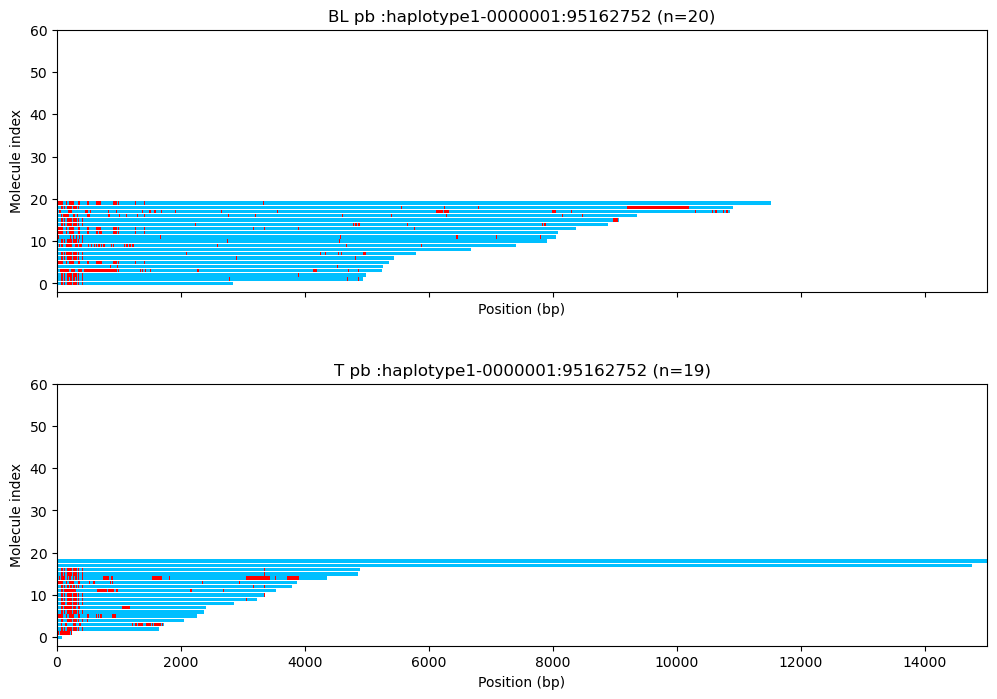

haplotype1-0000002:3070


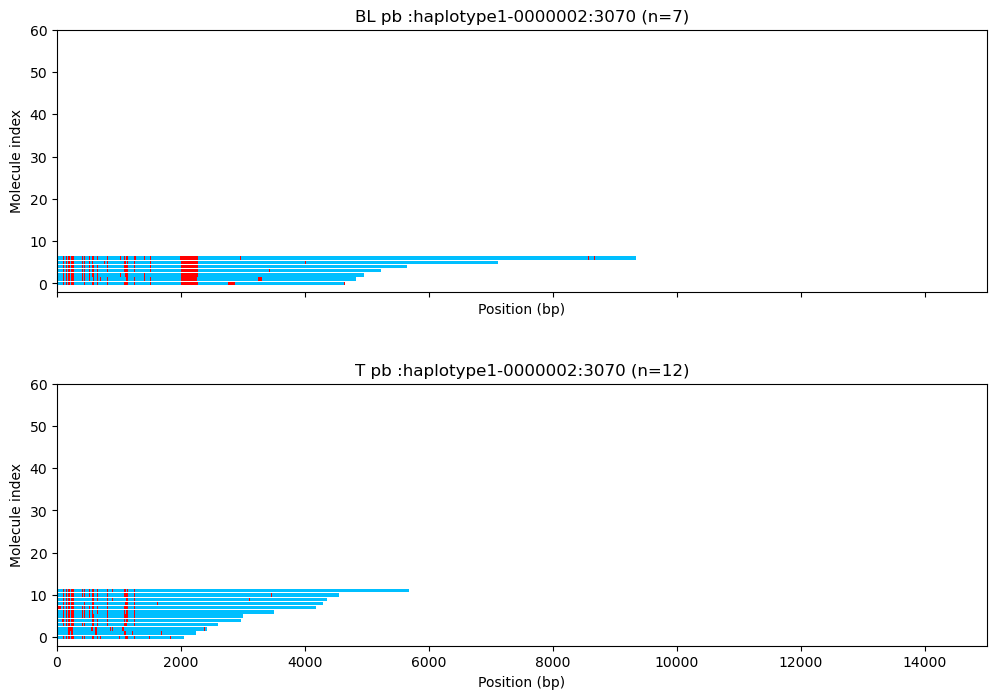

haplotype1-0000003:3510


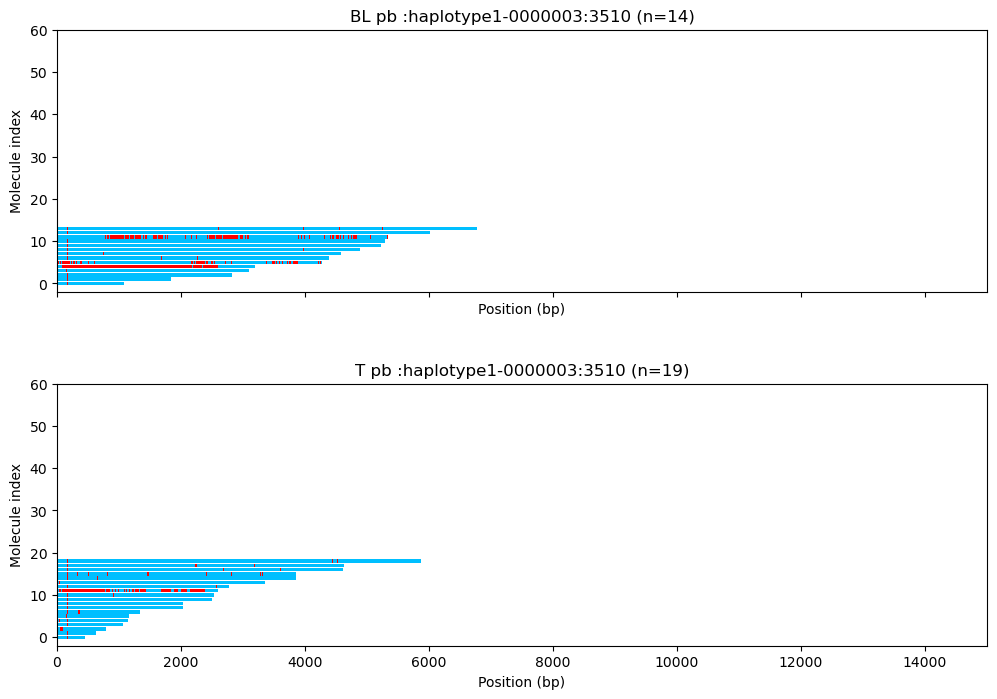

haplotype1-0000003:146990123


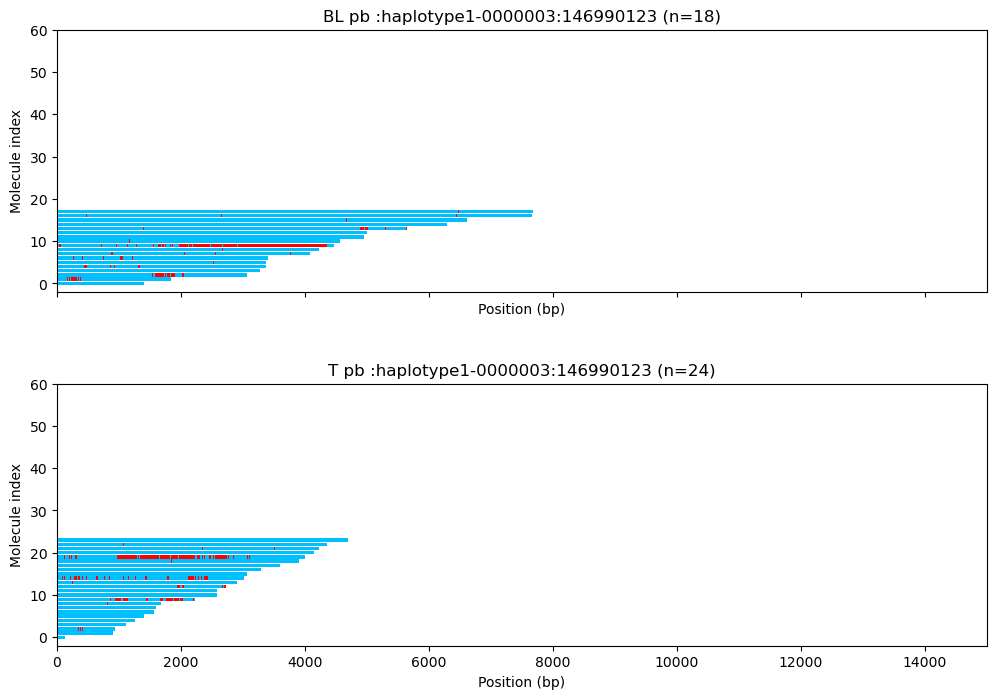

haplotype1-0000004:6362


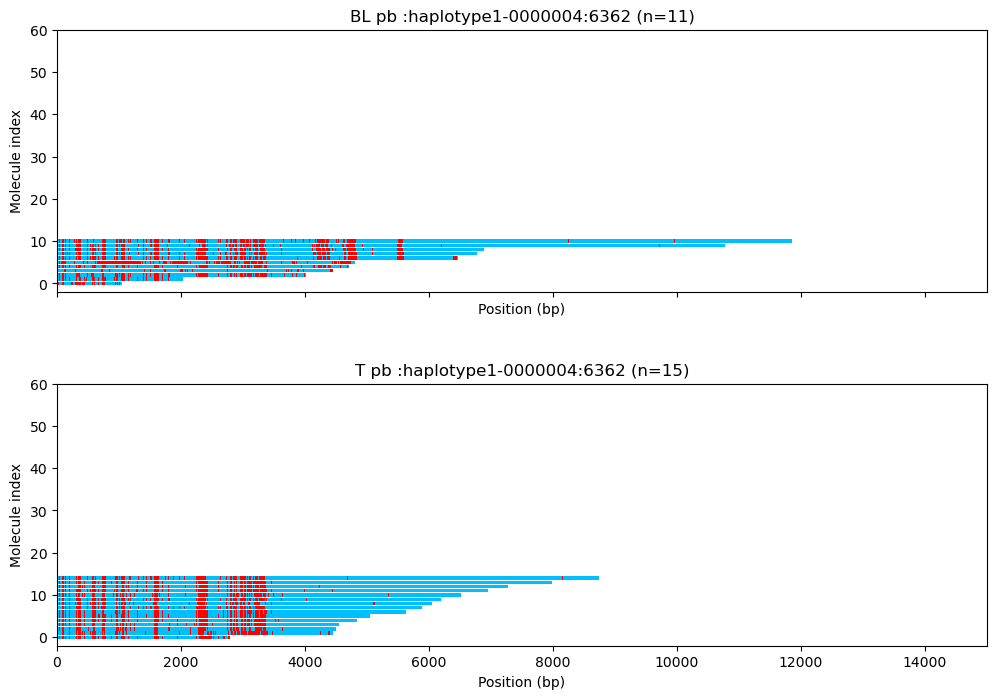

haplotype1-0000004:135163267


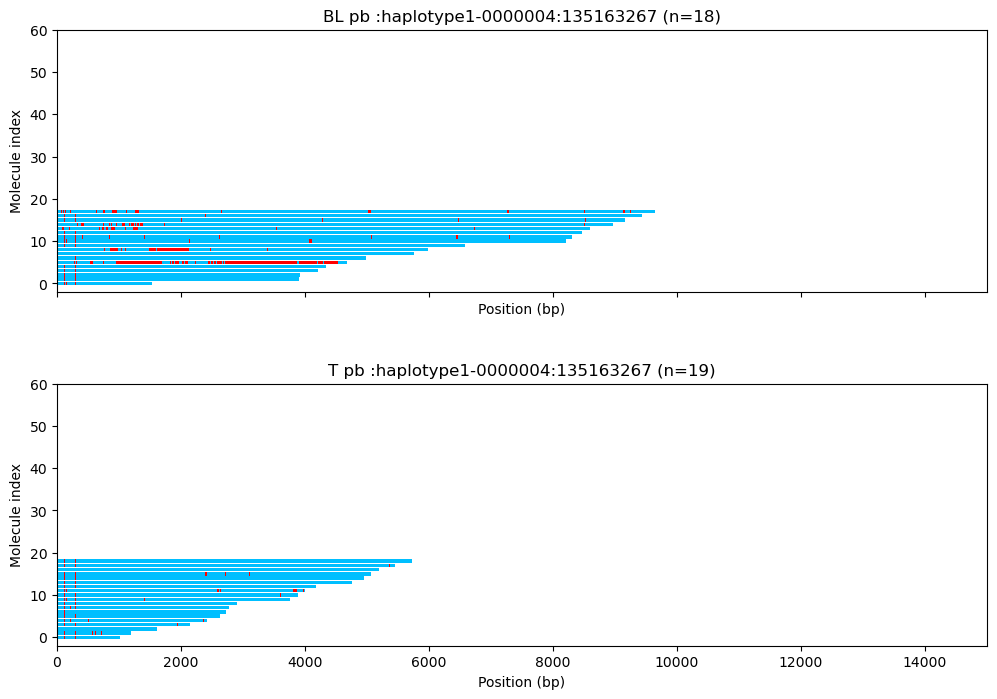

haplotype1-0000005:44327944


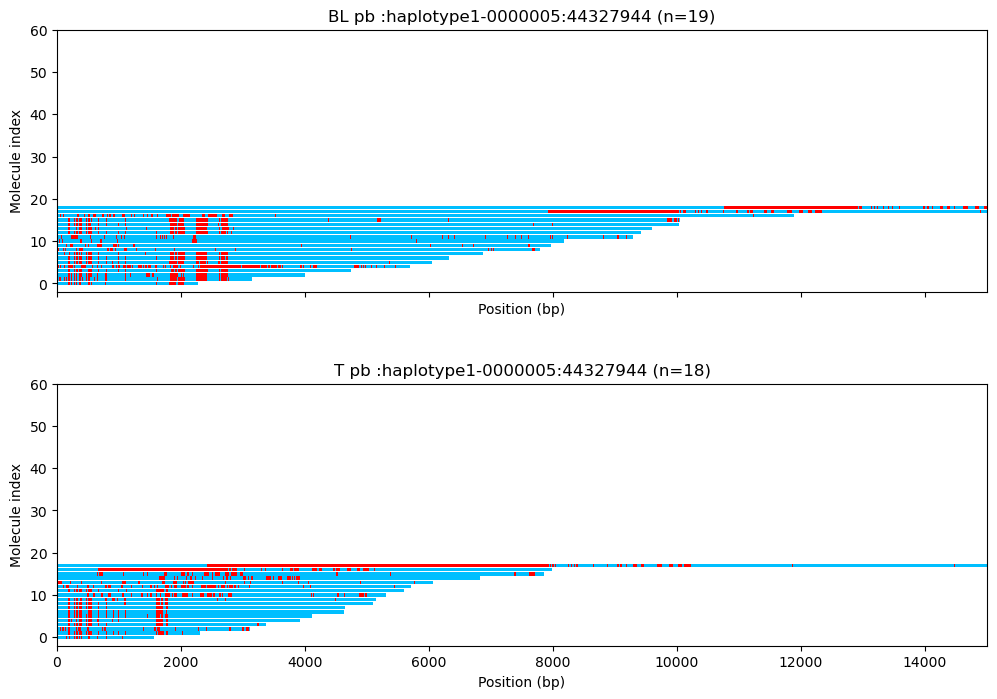

haplotype1-0000006:61912483


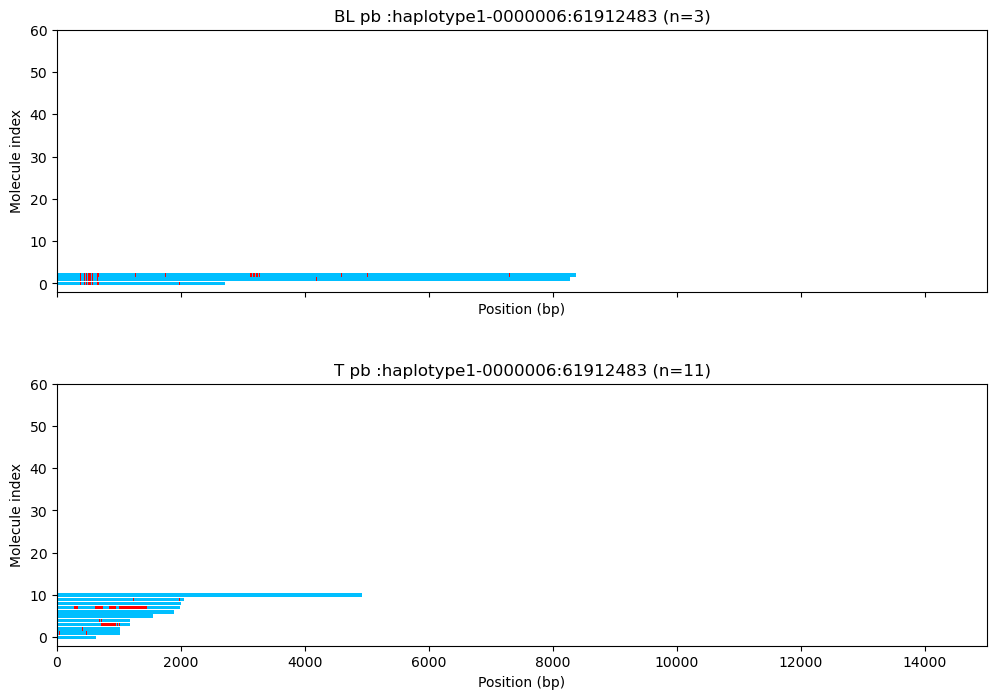

haplotype1-0000007:3999


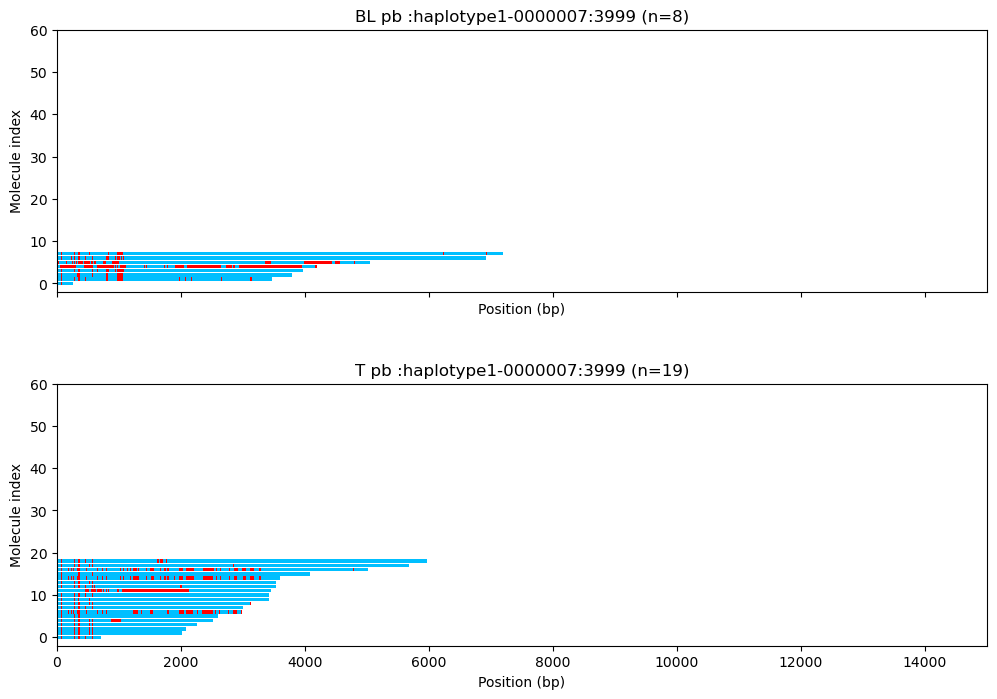

haplotype1-0000008:76728228


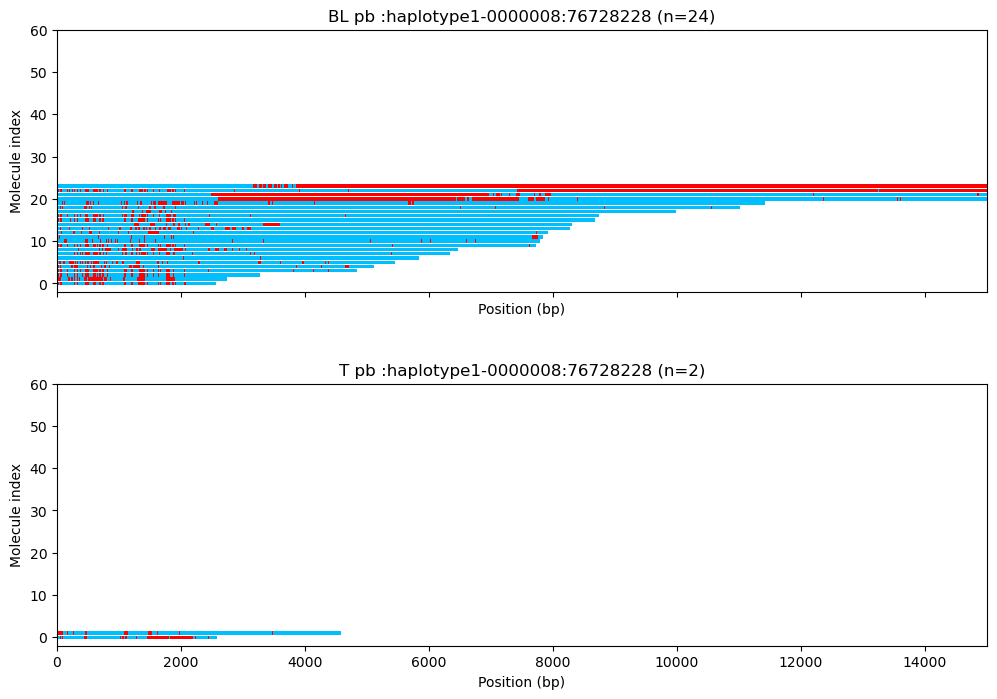

haplotype1-0000010:2163


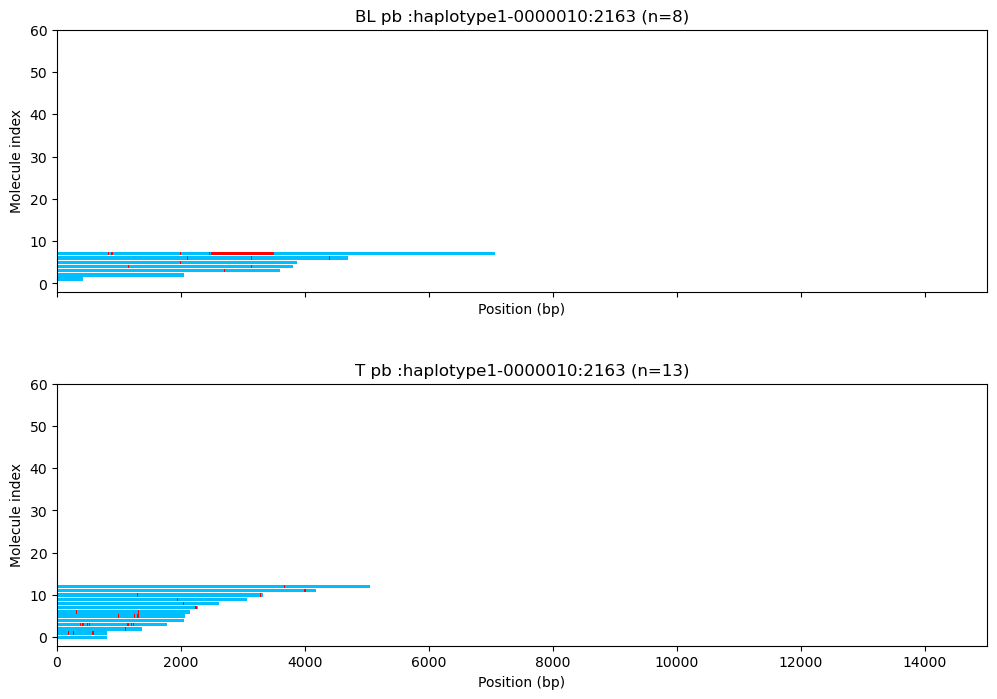

haplotype1-0000010:182746313


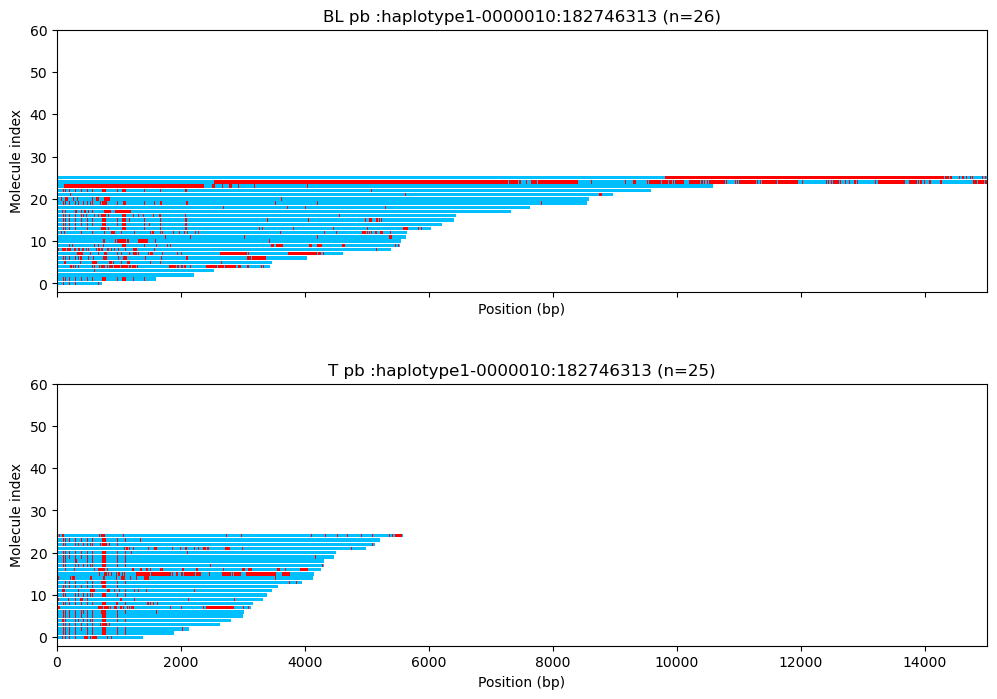

haplotype1-0000011:7301


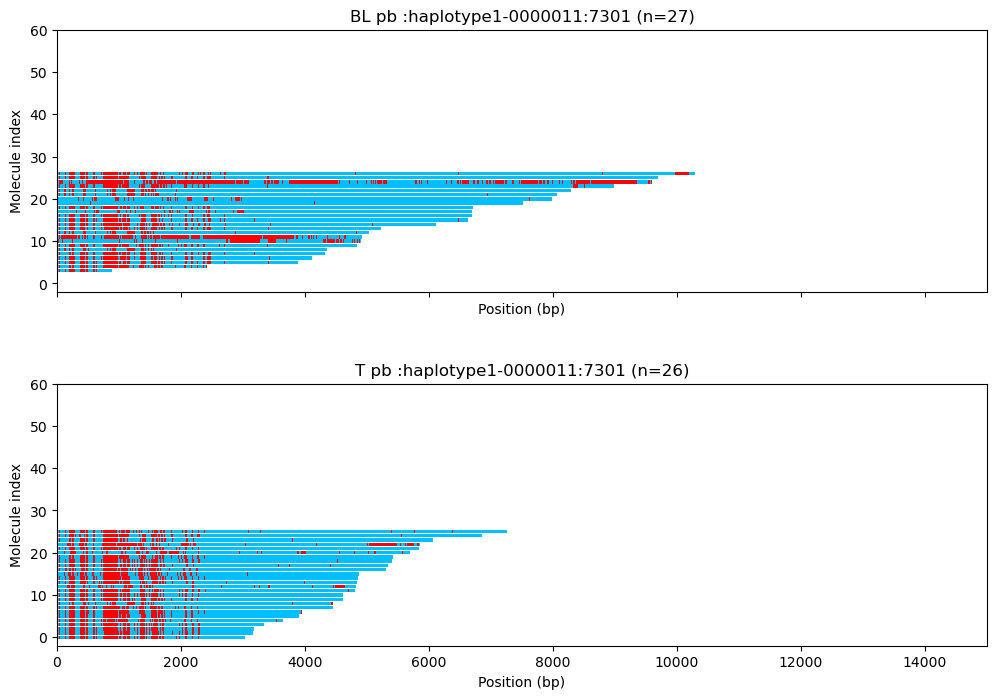

haplotype1-0000011:200085404


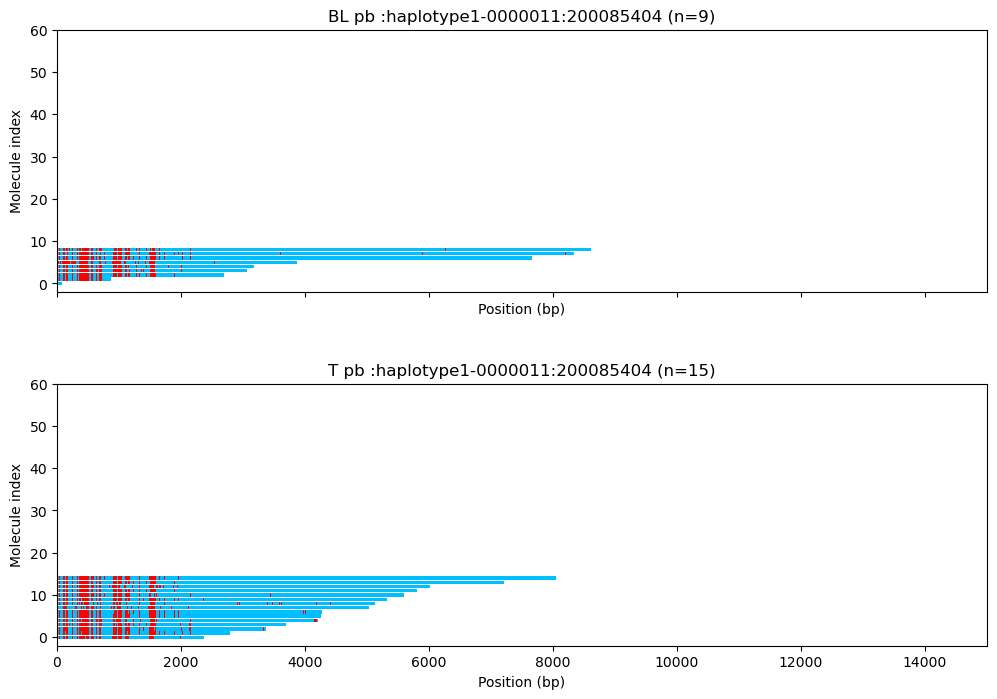

haplotype1-0000012:6362


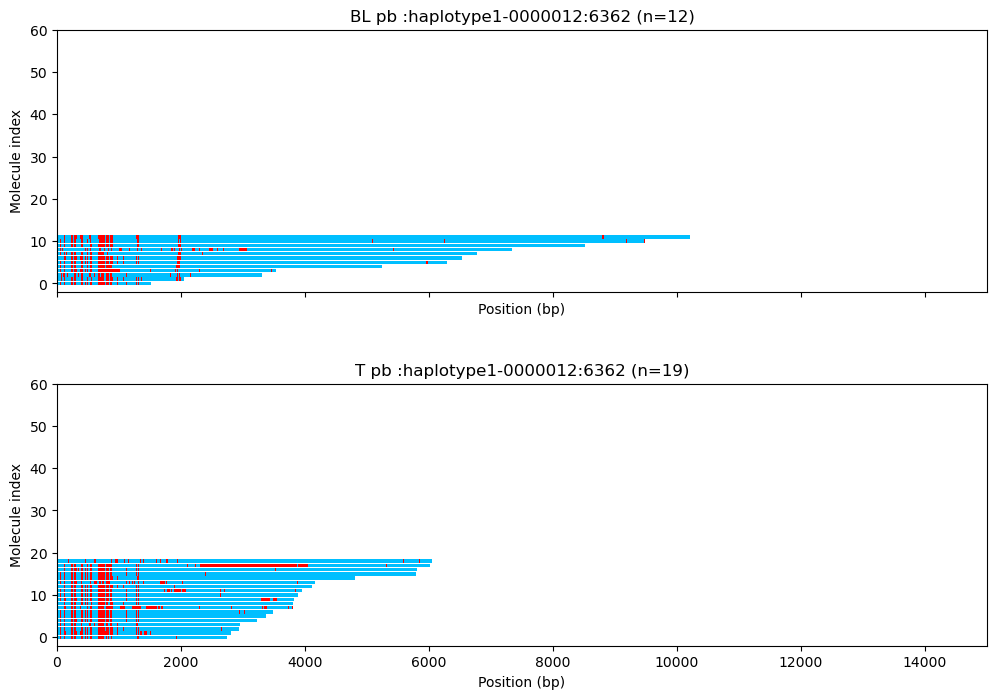

haplotype1-0000012:249077212


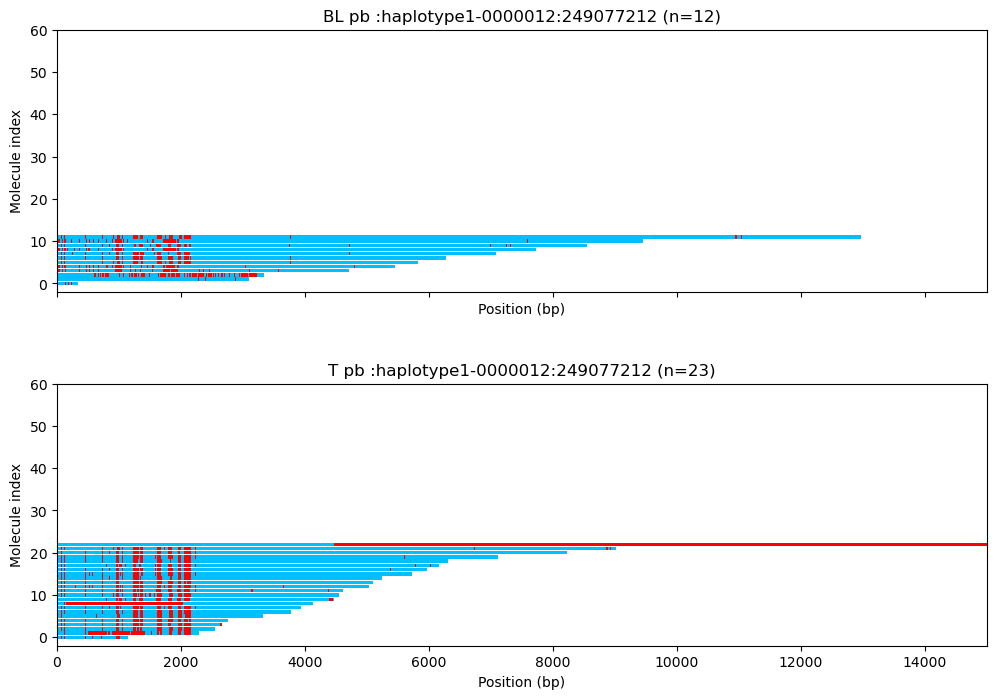

haplotype1-0000013:1939


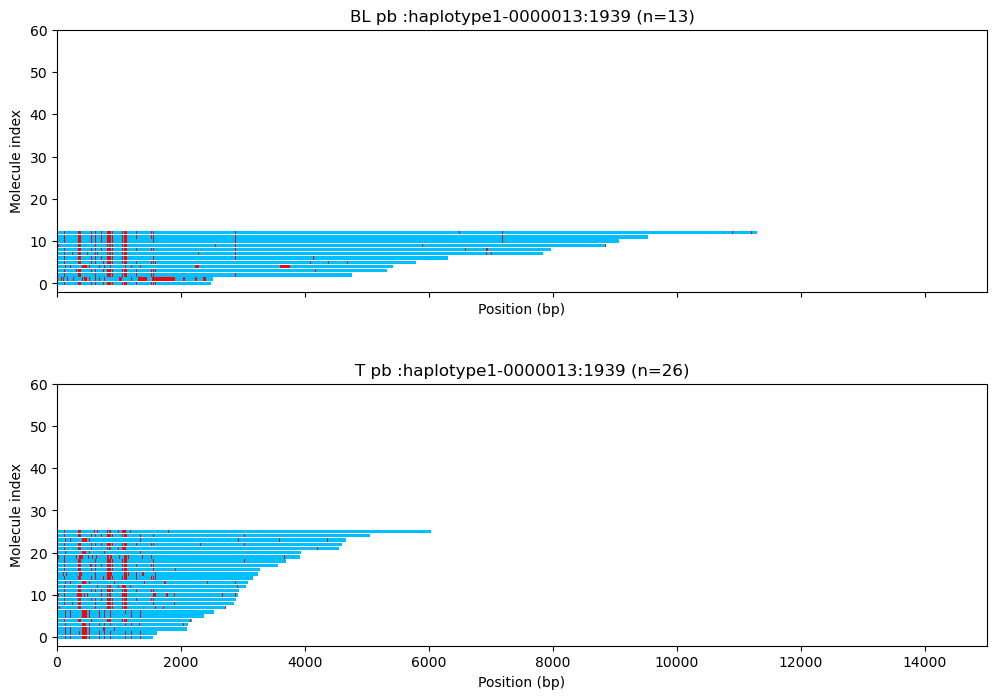

haplotype1-0000014:4366


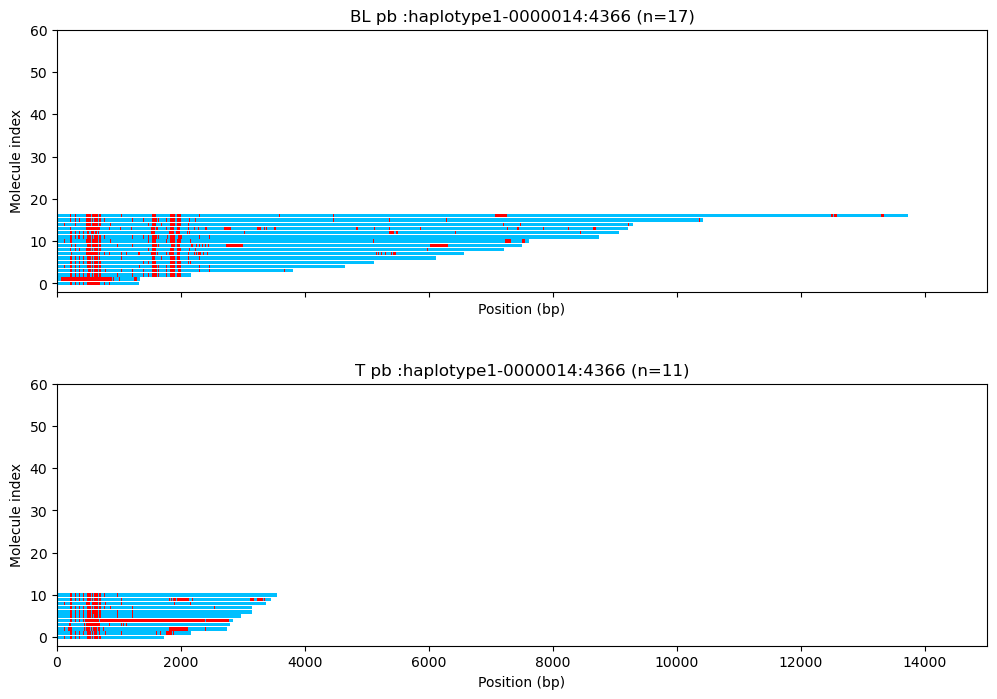

haplotype1-0000014:81824243


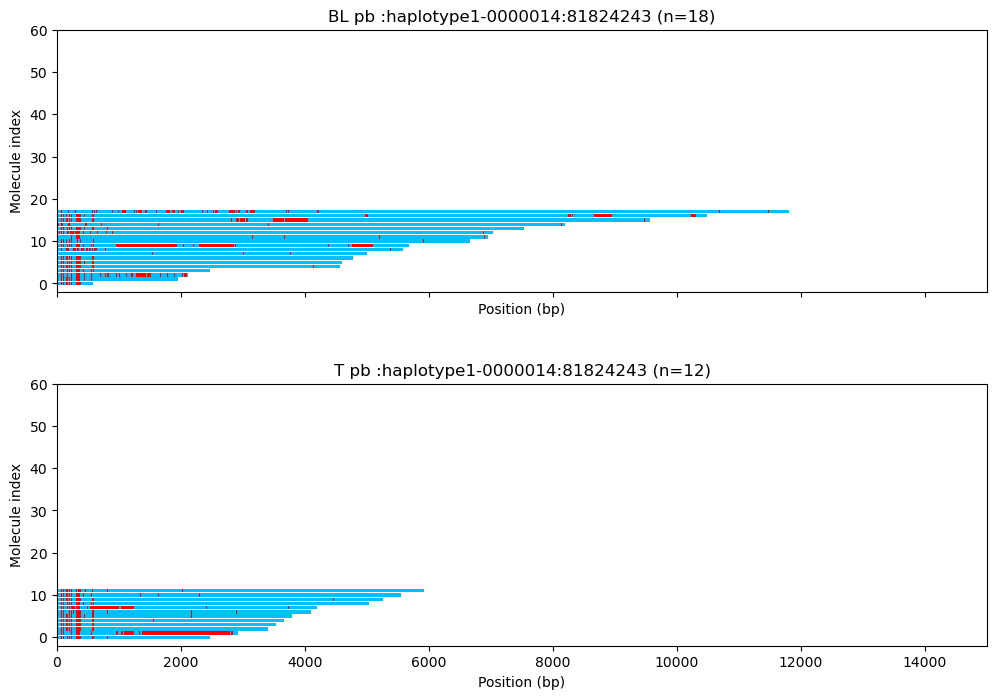

haplotype1-0000015:1796


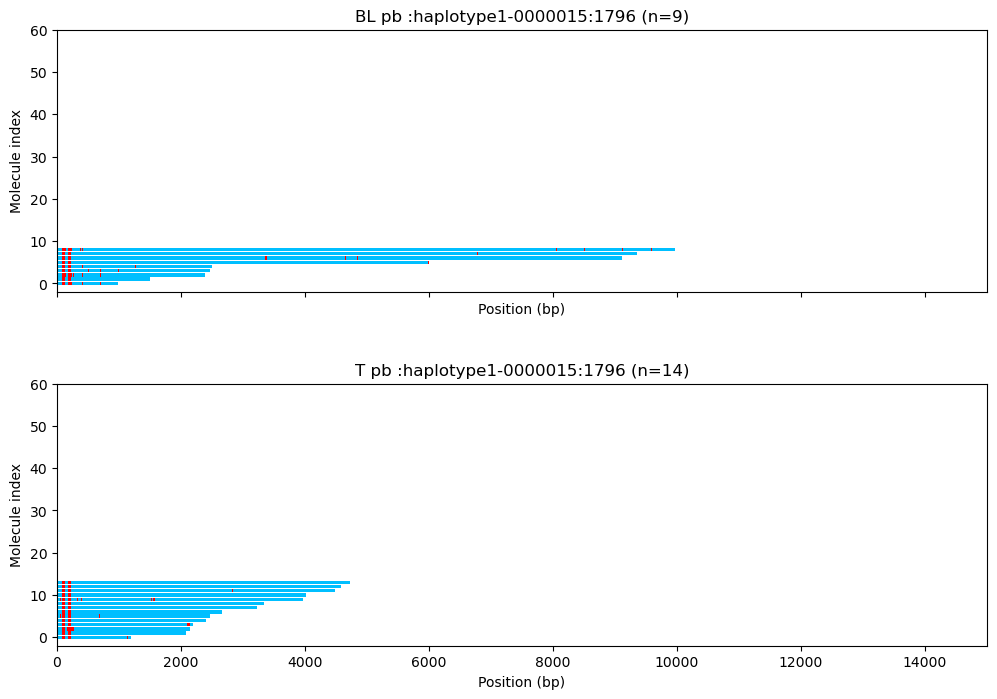

haplotype1-0000015:79742090


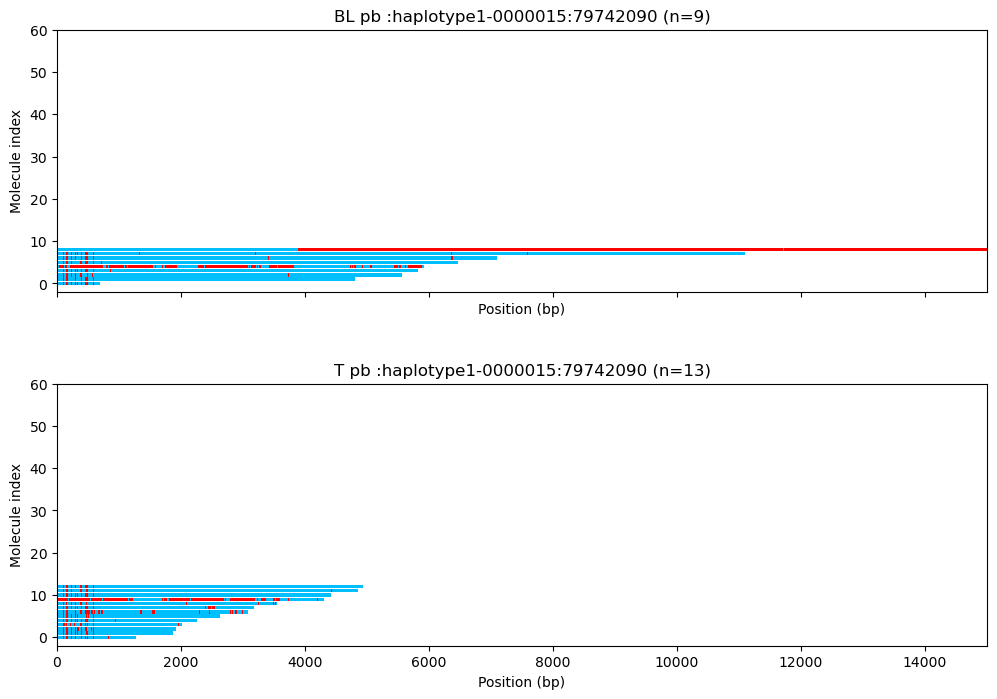

haplotype1-0000016:18399927


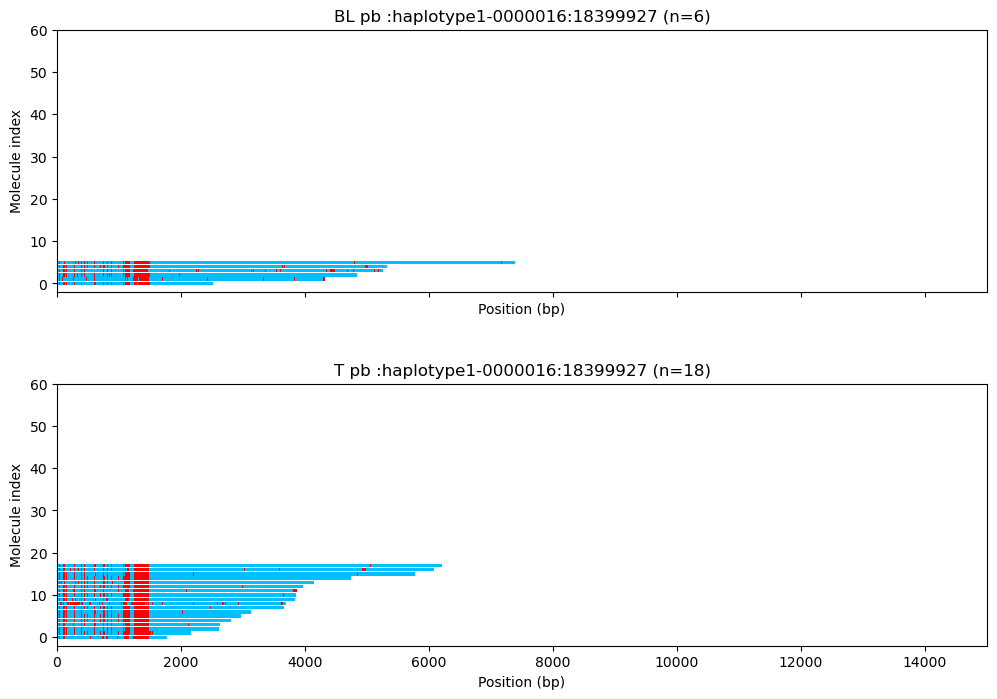

haplotype1-0000017:5458


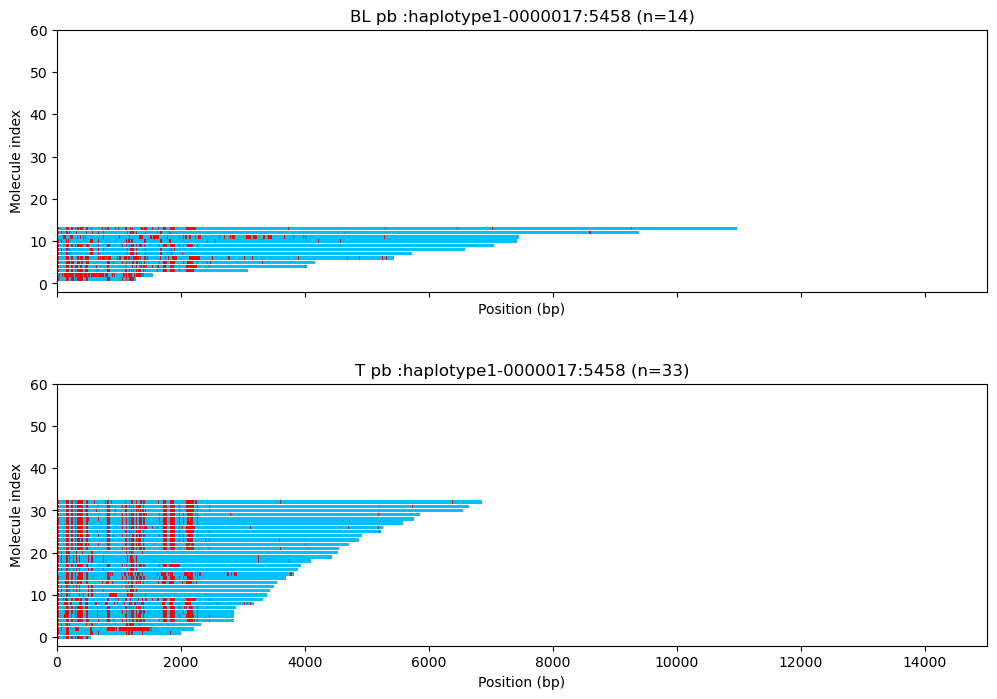

haplotype1-0000017:134455455


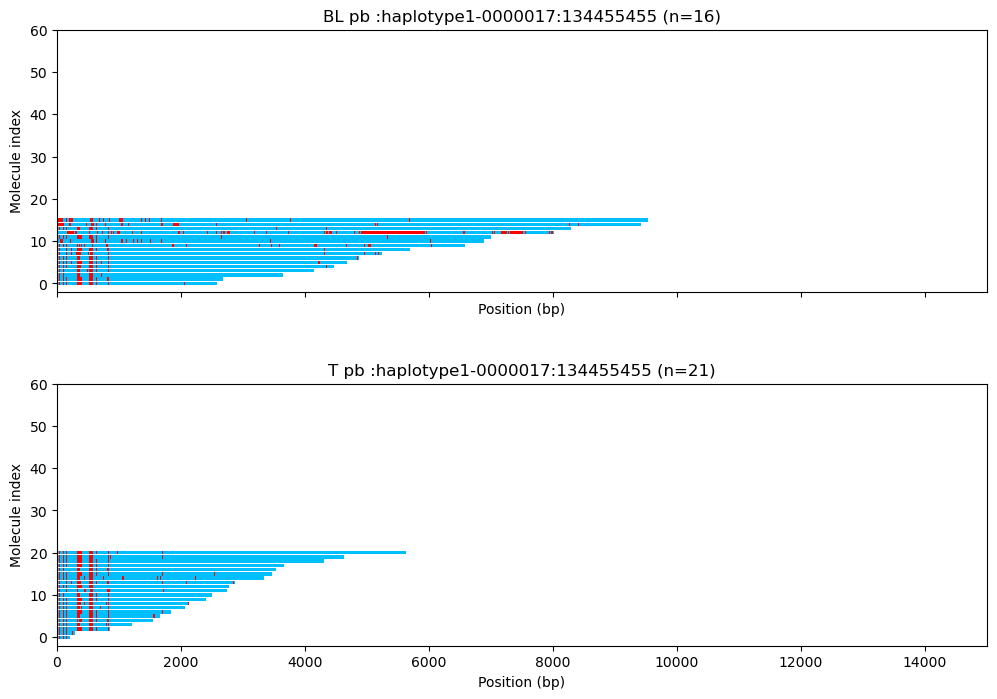

haplotype1-0000018:96803608


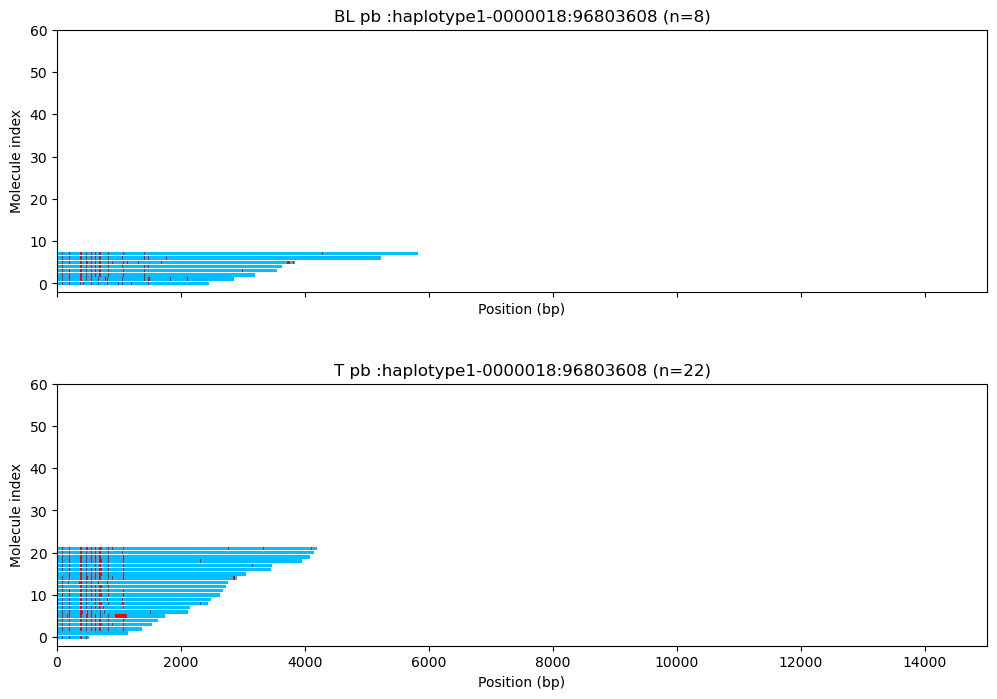

haplotype1-0000019:7801


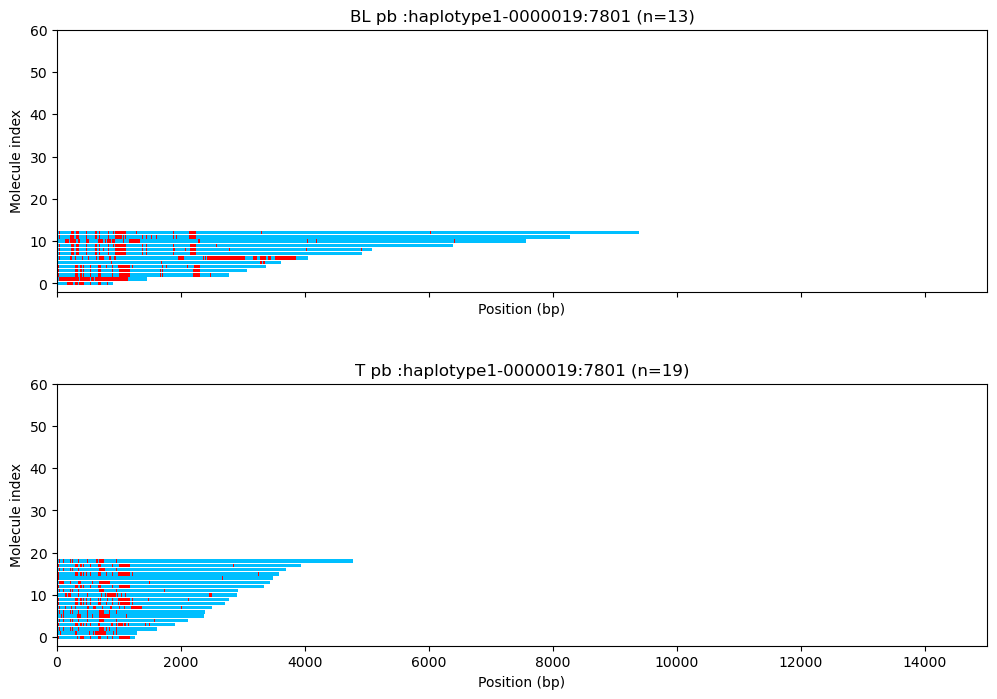

haplotype1-0000021:4806


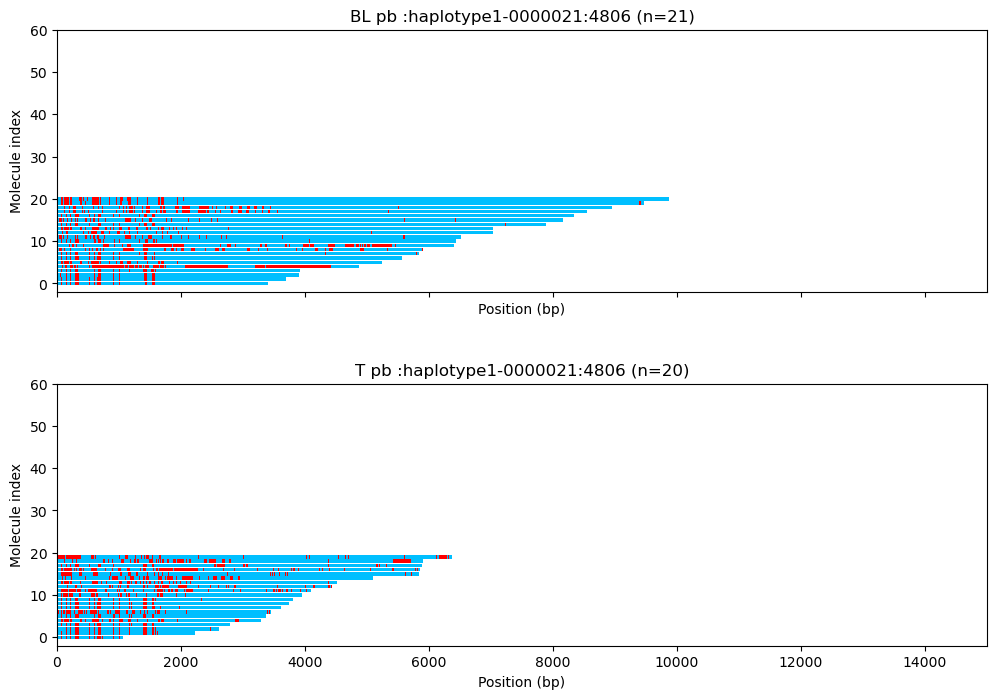

haplotype1-0000021:133807714


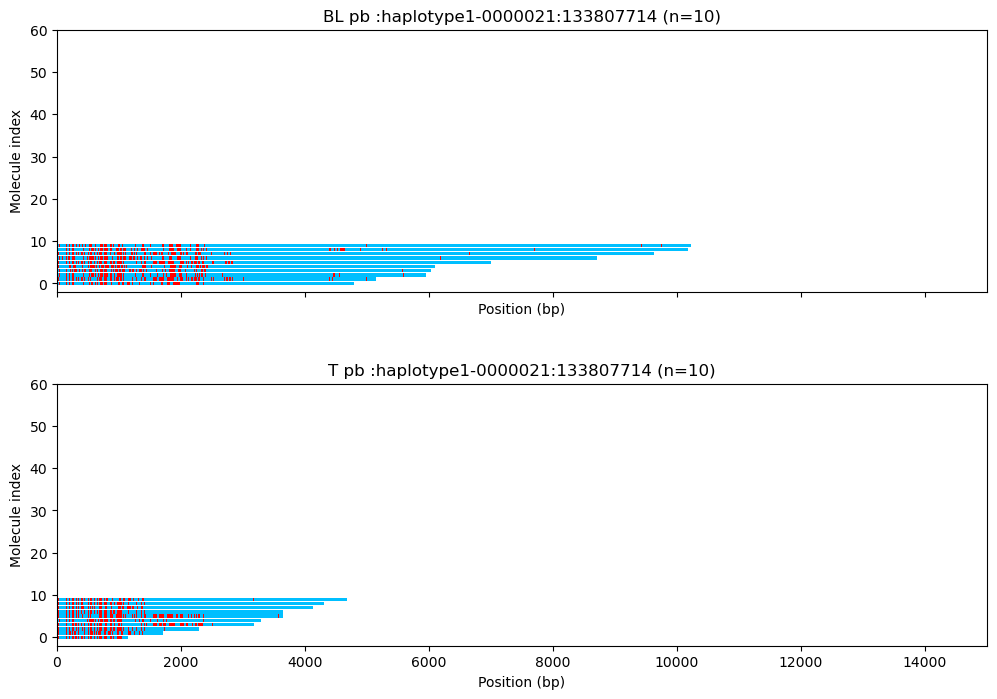

haplotype1-0000022:75165418


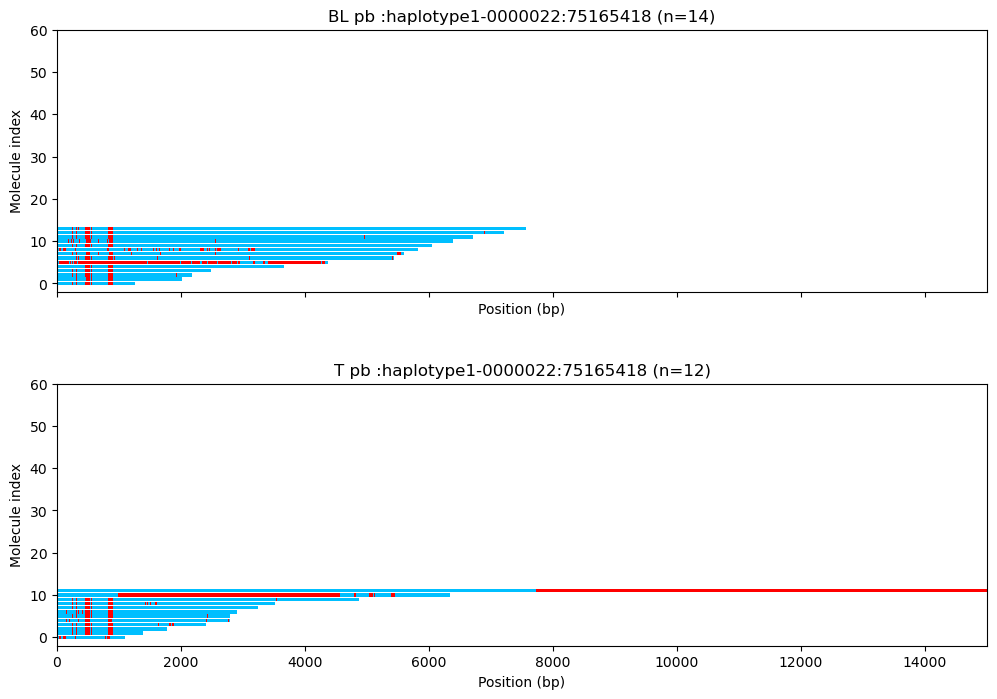

haplotype1-0000023:941


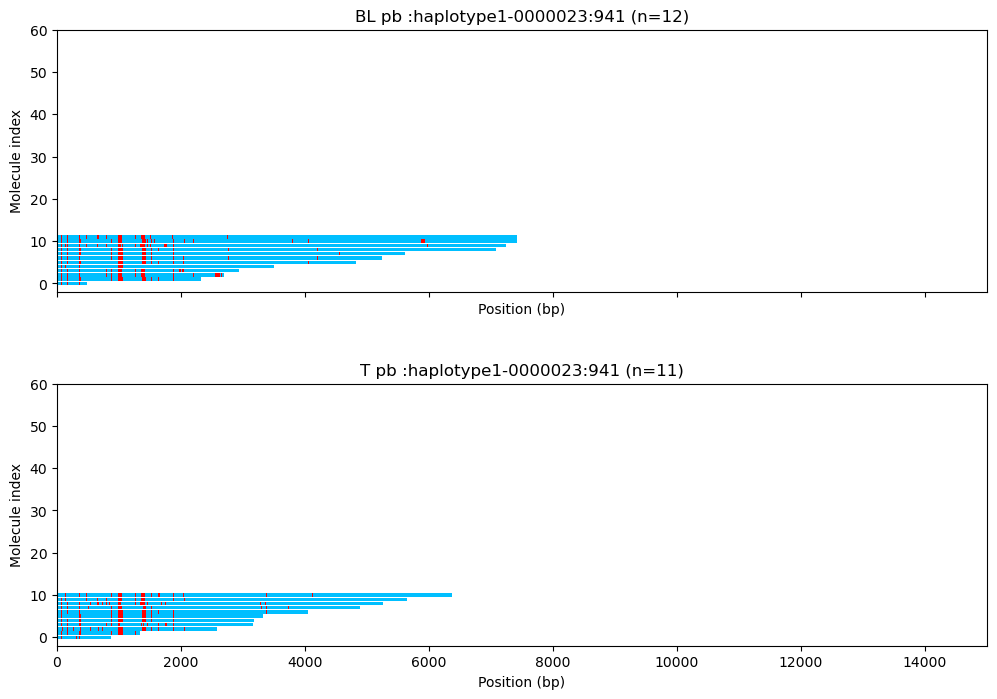

haplotype1-0000023:42814895


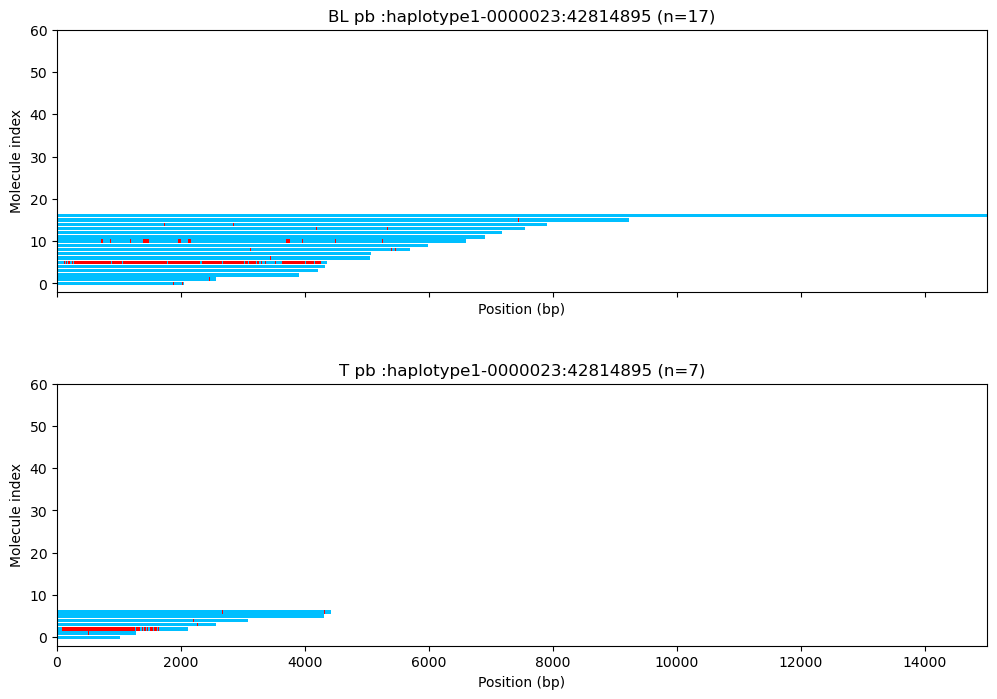

haplotype1-0000024:147710412


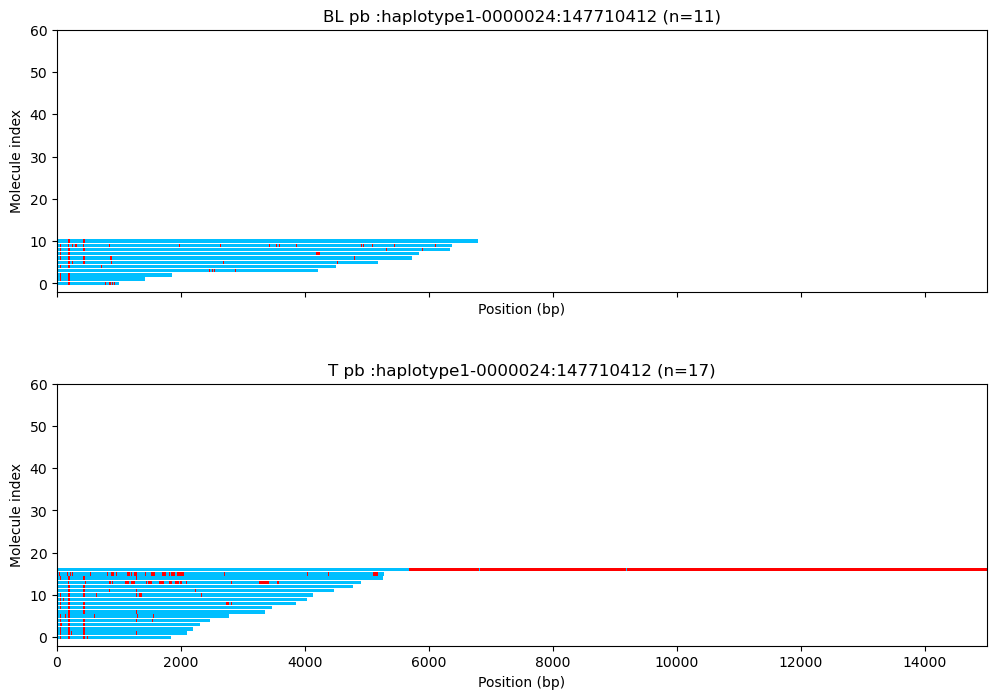

haplotype1-0000025:25180848


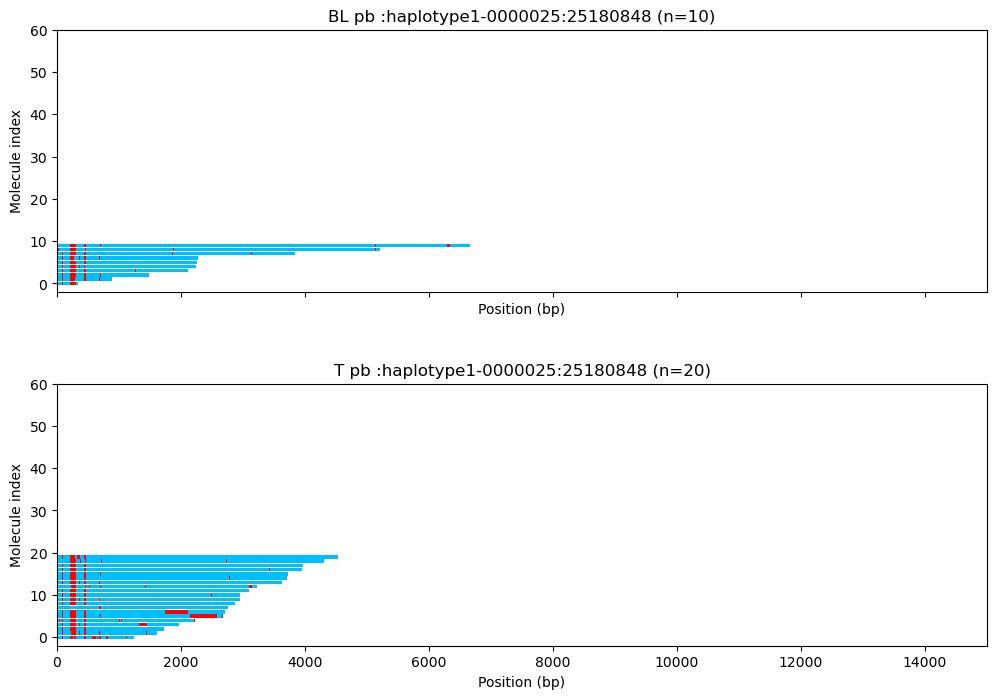

haplotype1-0000026:2420


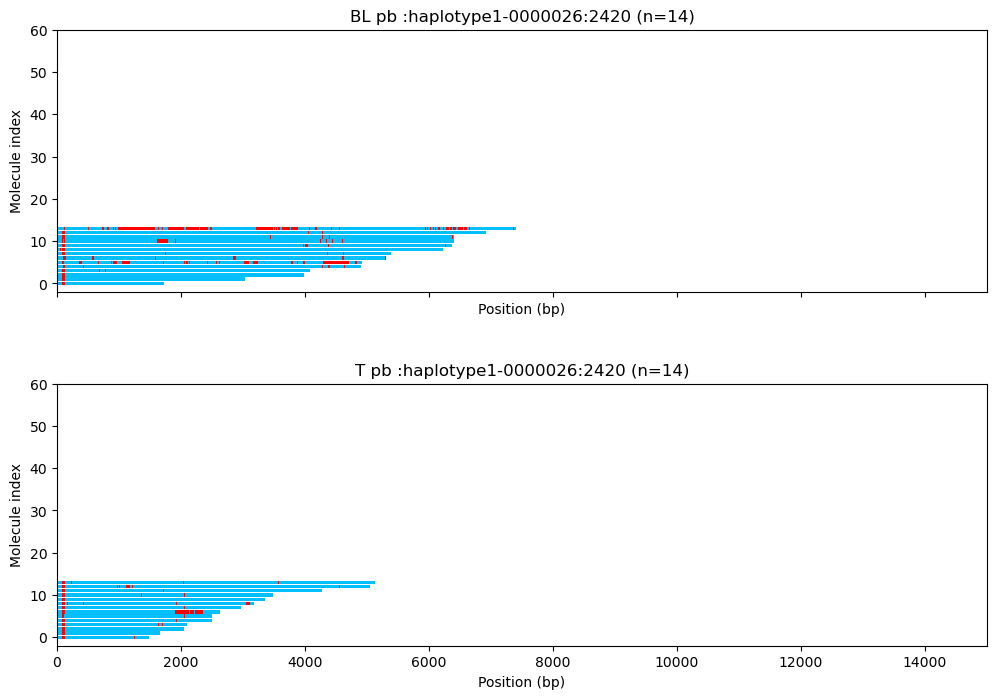

haplotype1-0000026:172187974


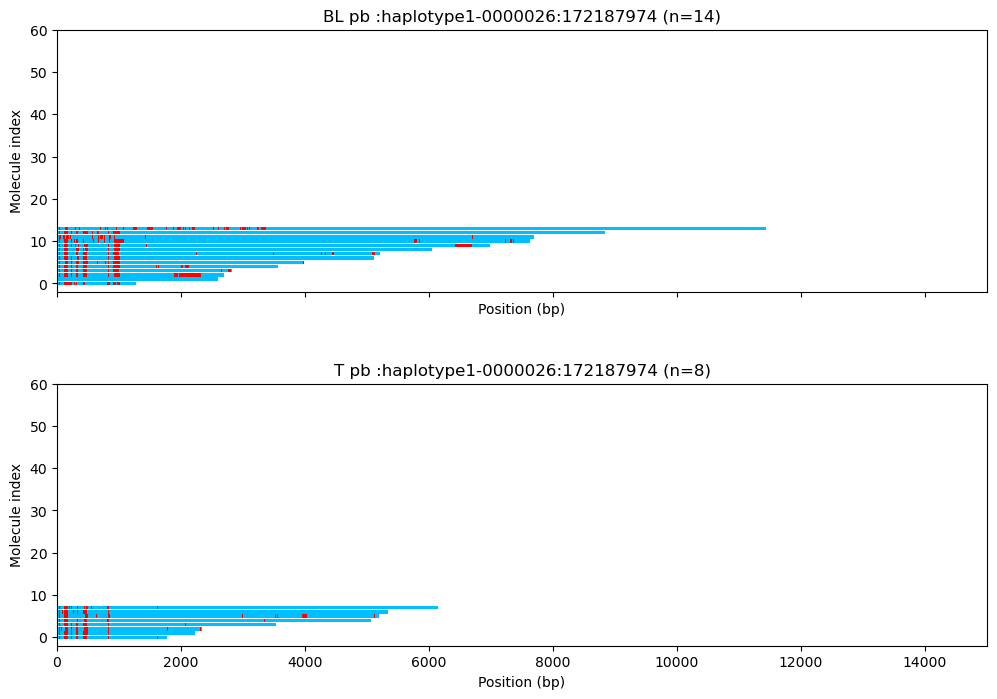

haplotype1-0000027:2712


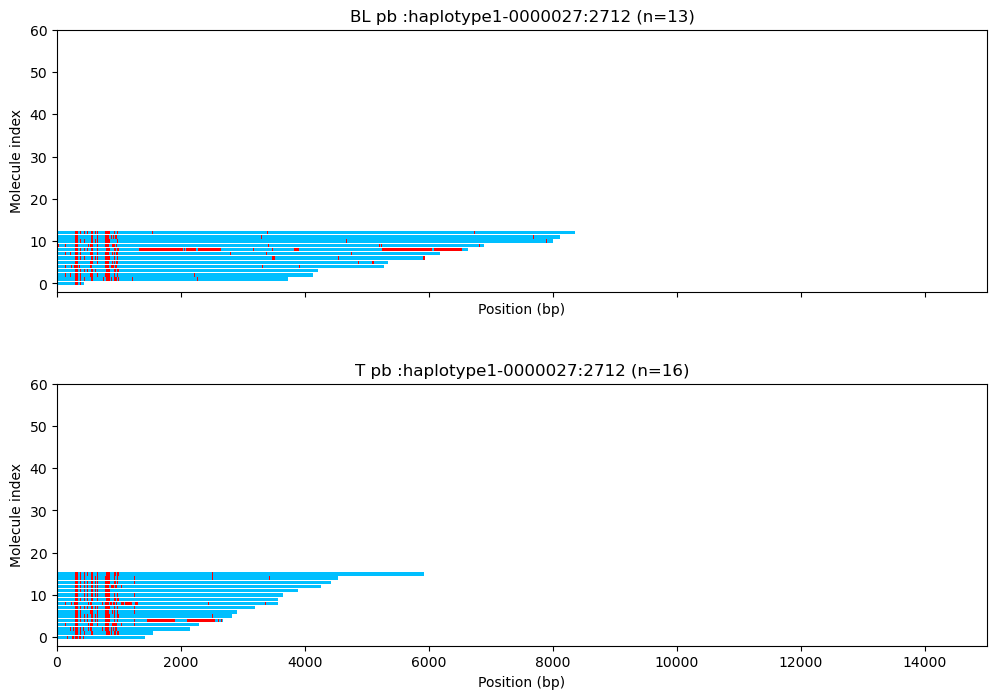

haplotype1-0000027:155565016


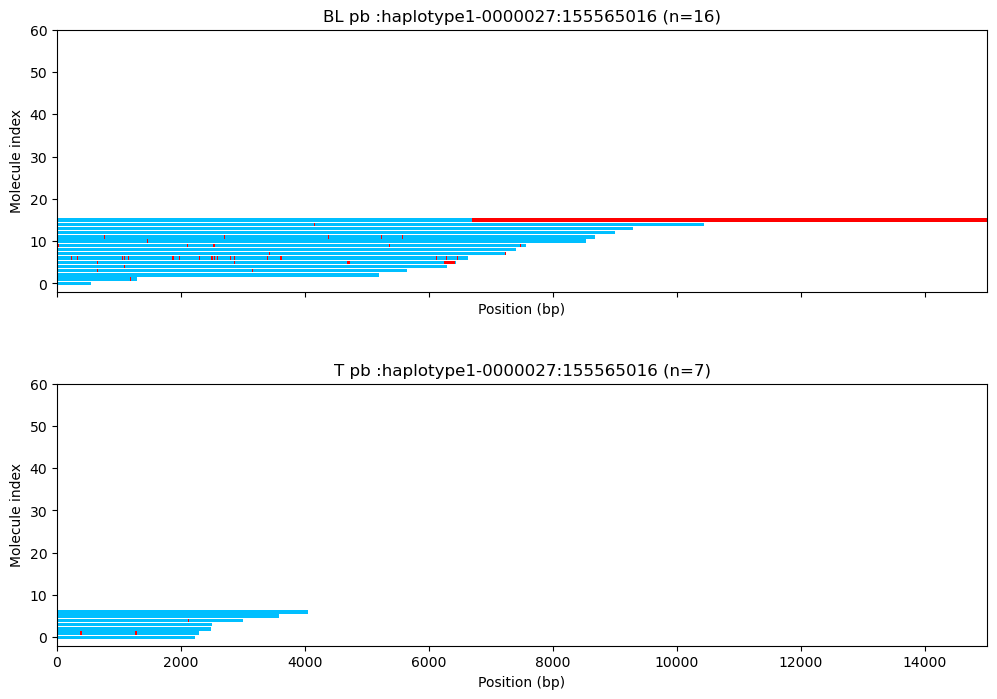

haplotype1-0000028:51715657


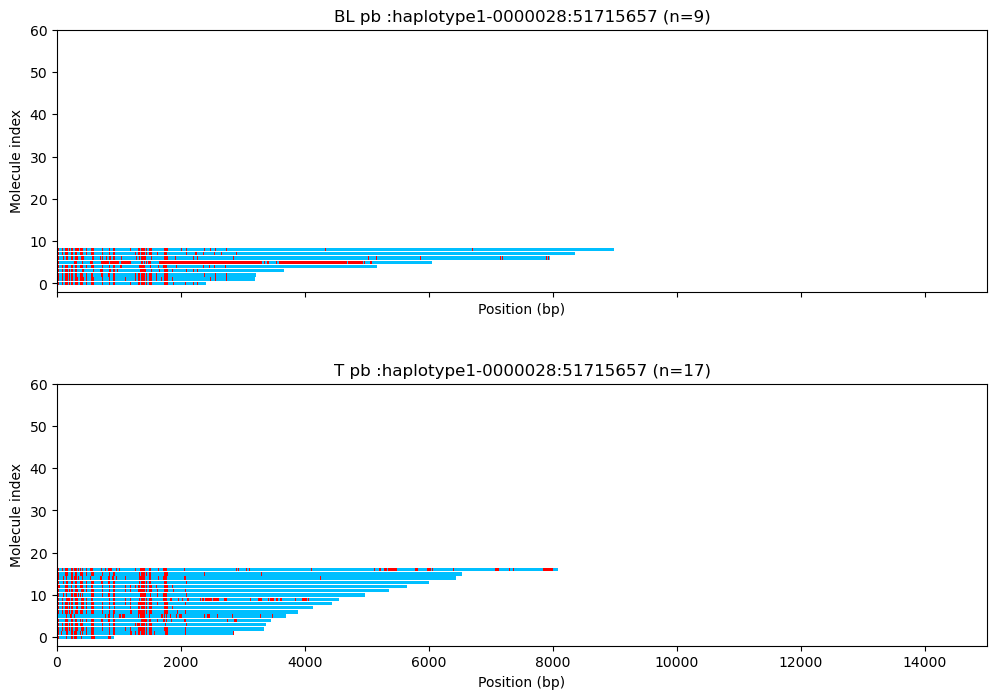

haplotype2-0000048:5299


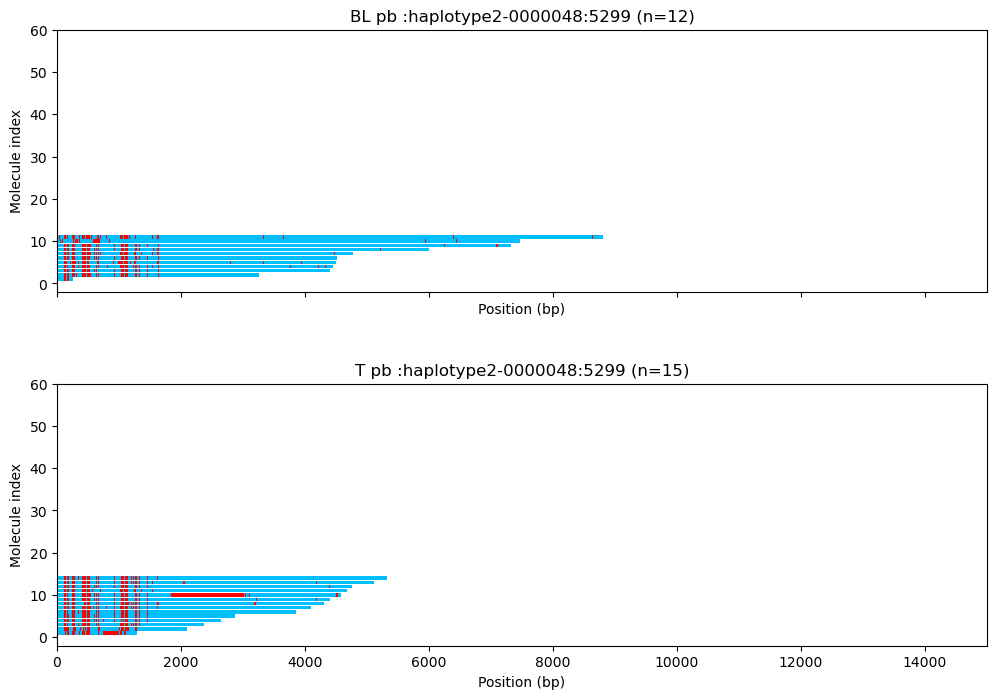

haplotype2-0000048:84346615


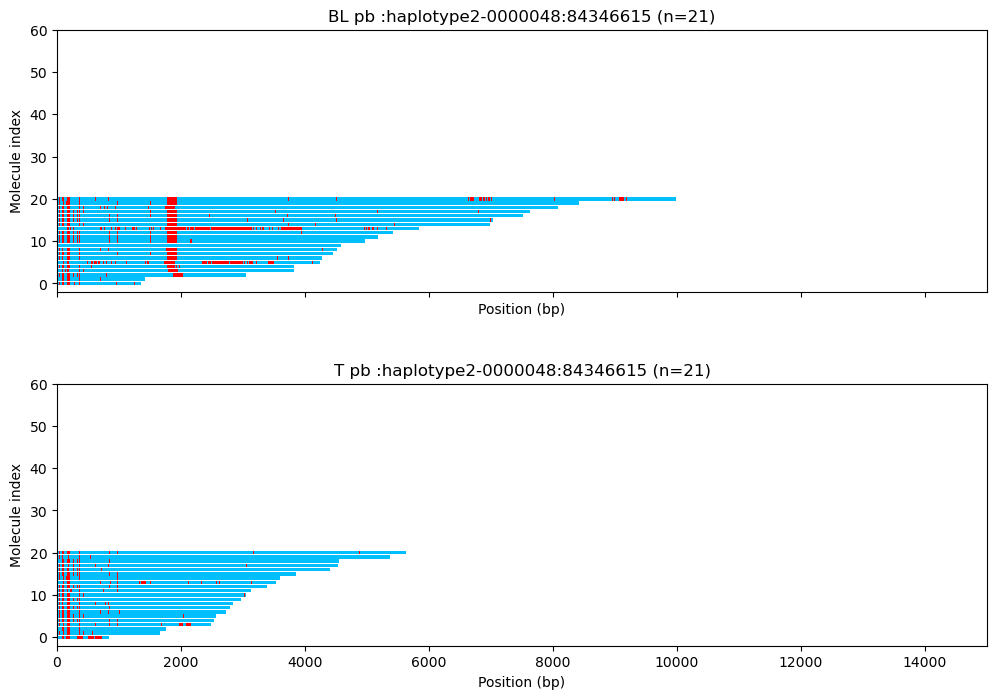

haplotype2-0000049:24917834


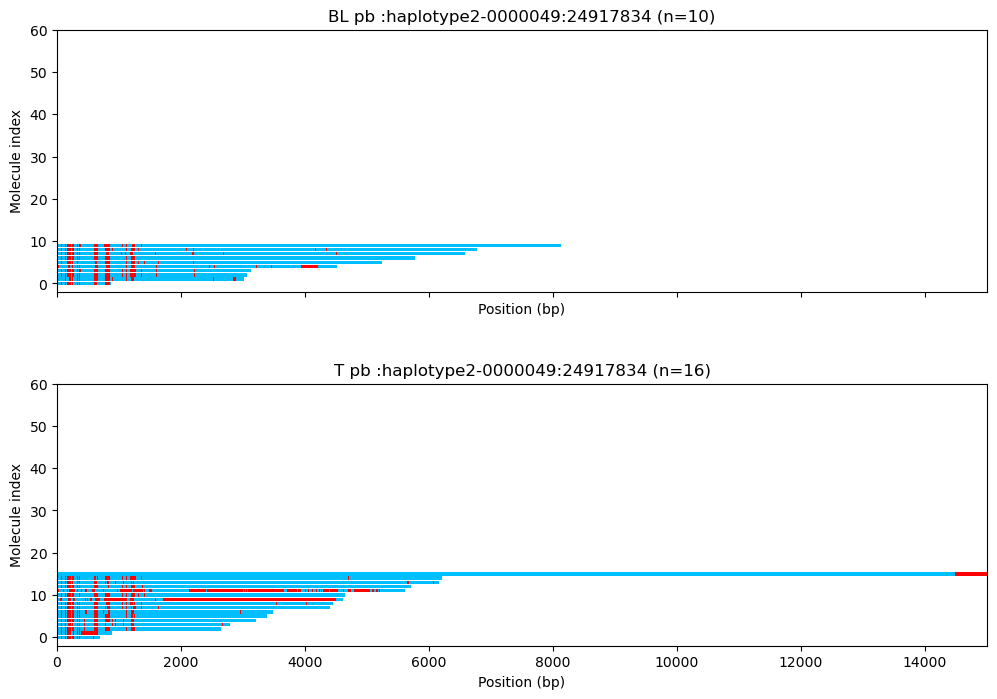

haplotype2-0000050:3263


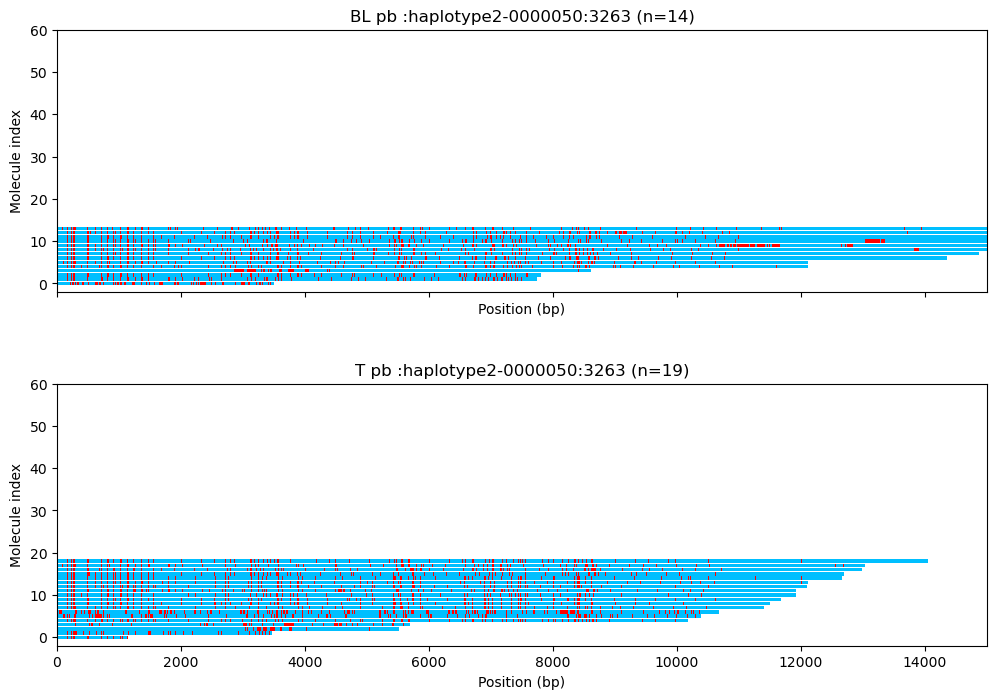

haplotype2-0000050:110557993


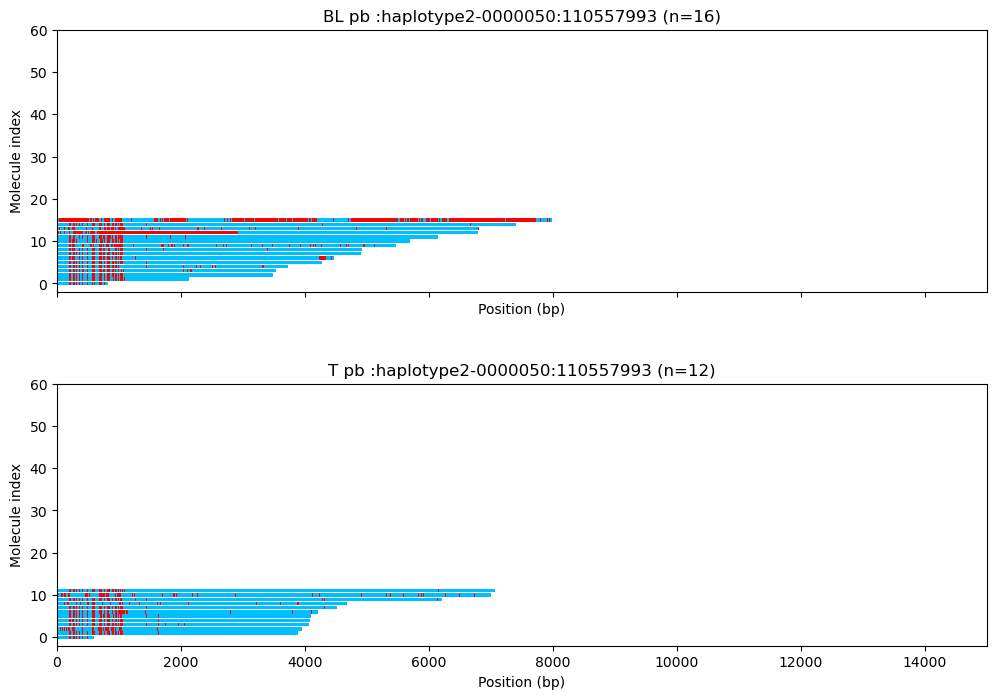

haplotype2-0000051:1729


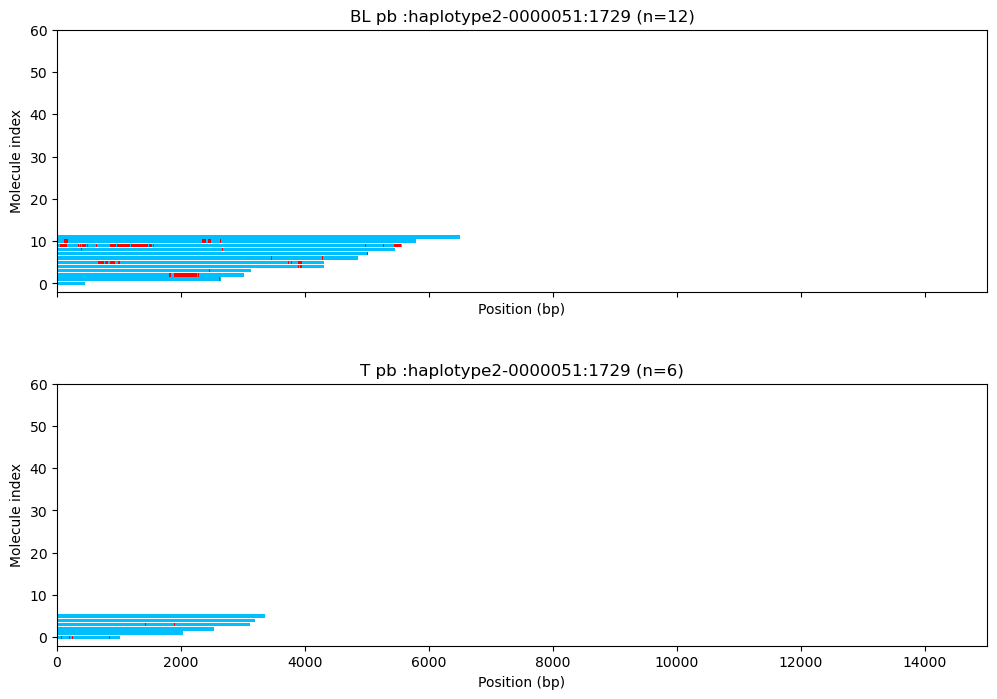

haplotype2-0000051:145631259


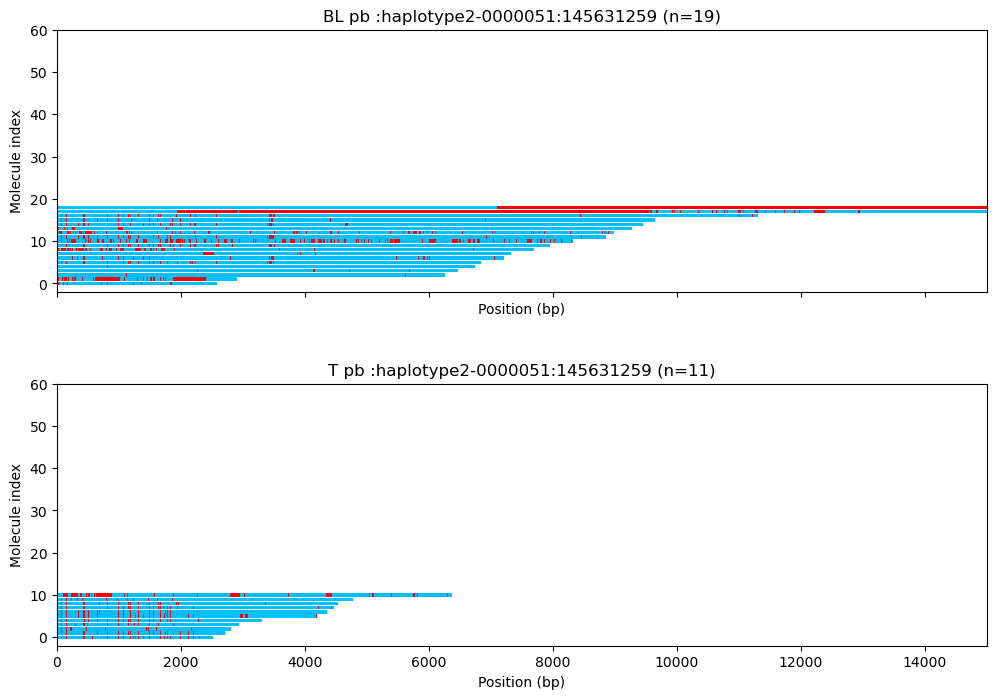

haplotype2-0000052:9022


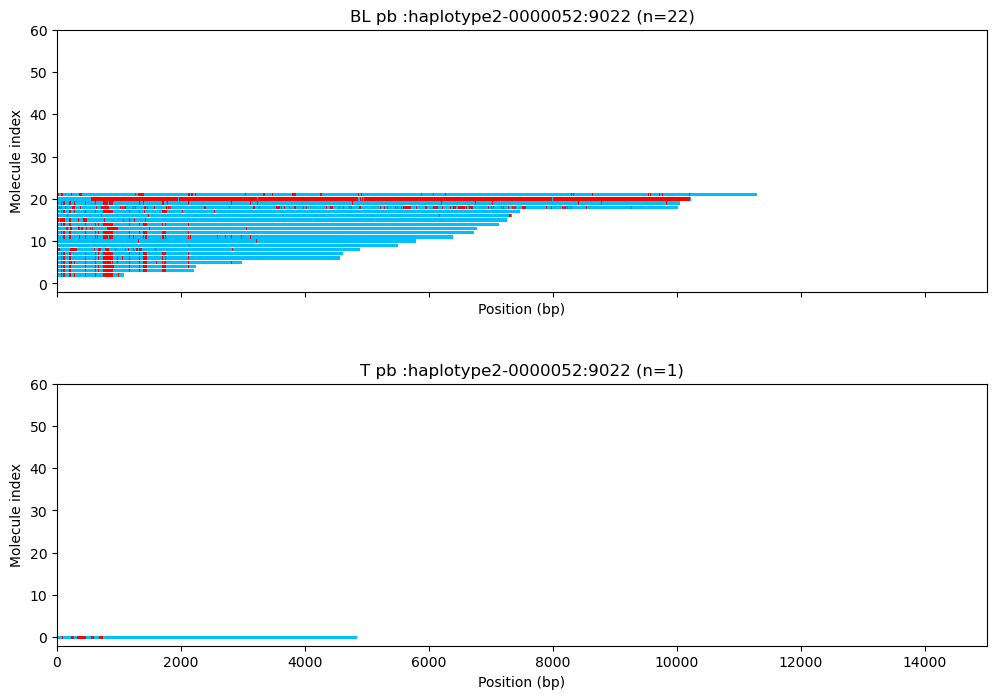

haplotype2-0000053:61665600


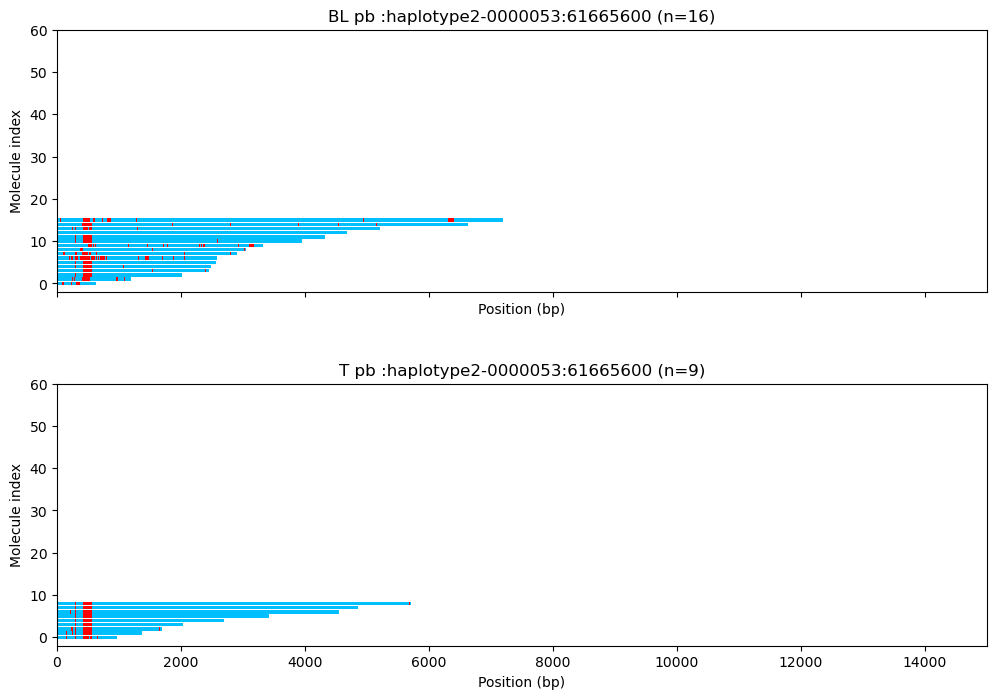

haplotype2-0000054:3999


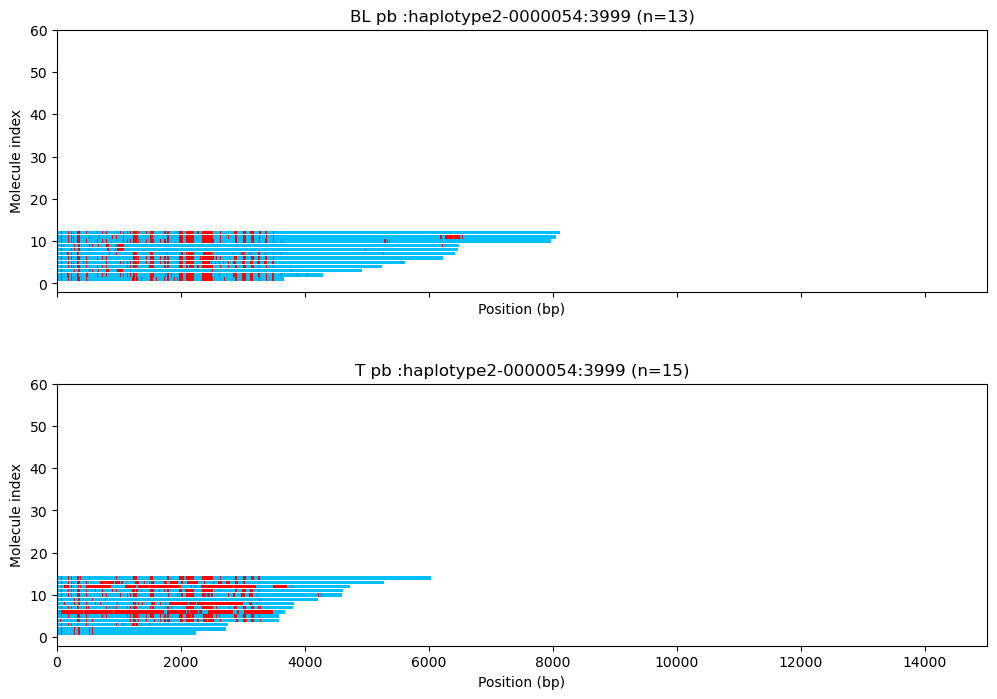

haplotype2-0000055:8877


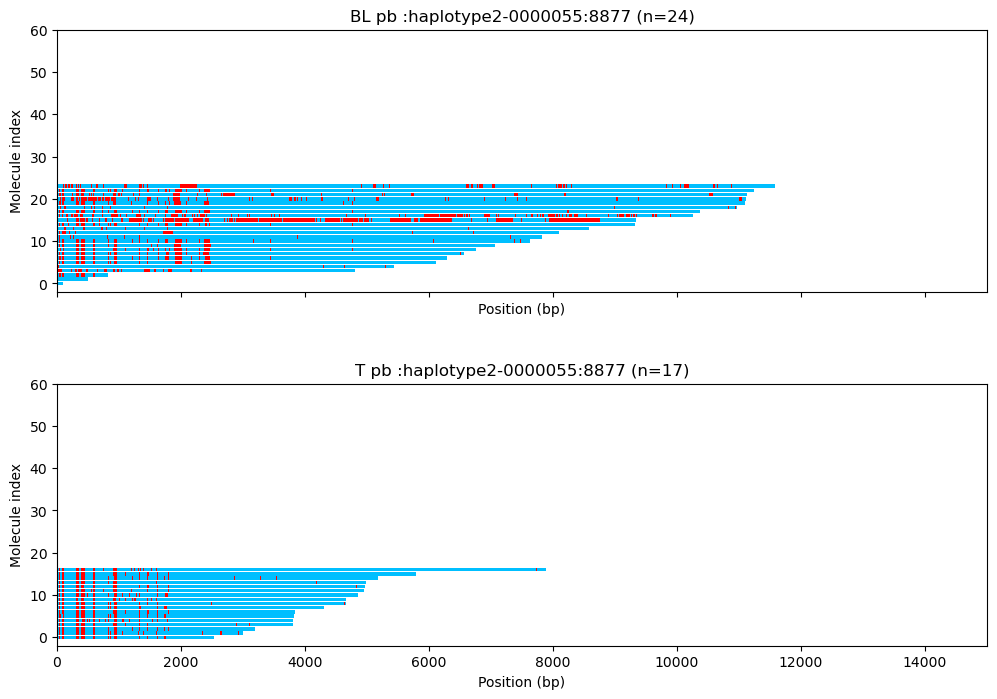

haplotype2-0000056:5425


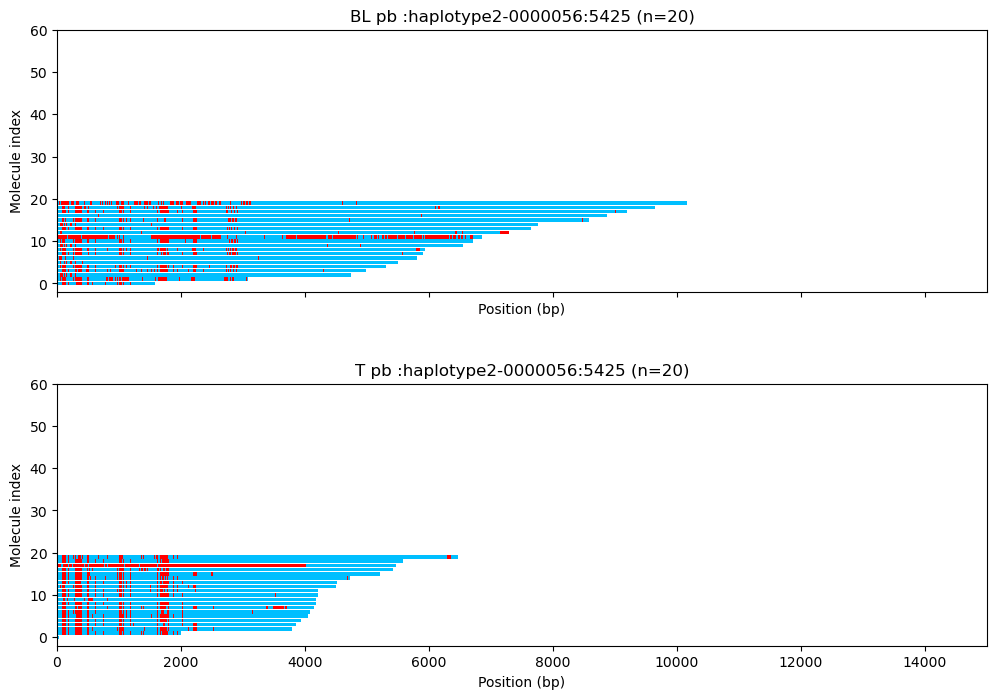

haplotype2-0000057:184981042


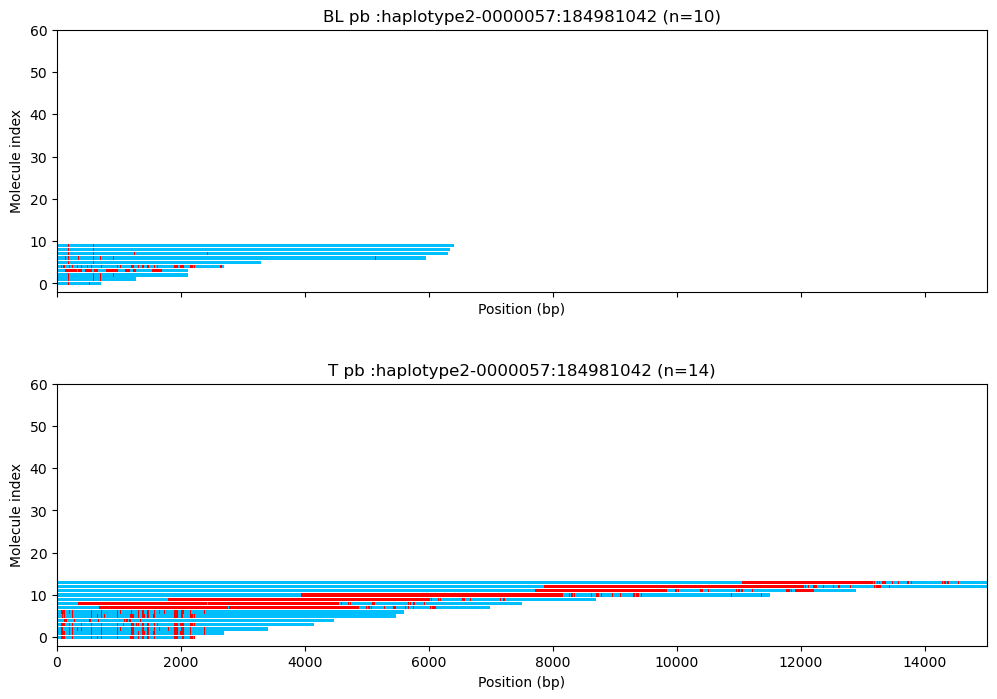

haplotype2-0000058:7301


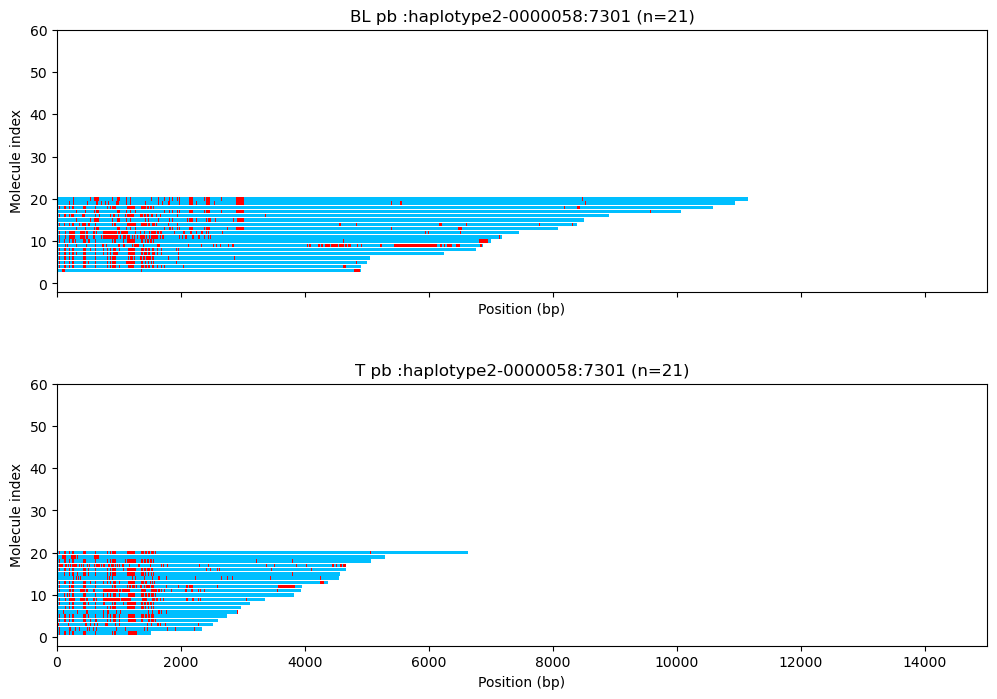

haplotype2-0000059:5093


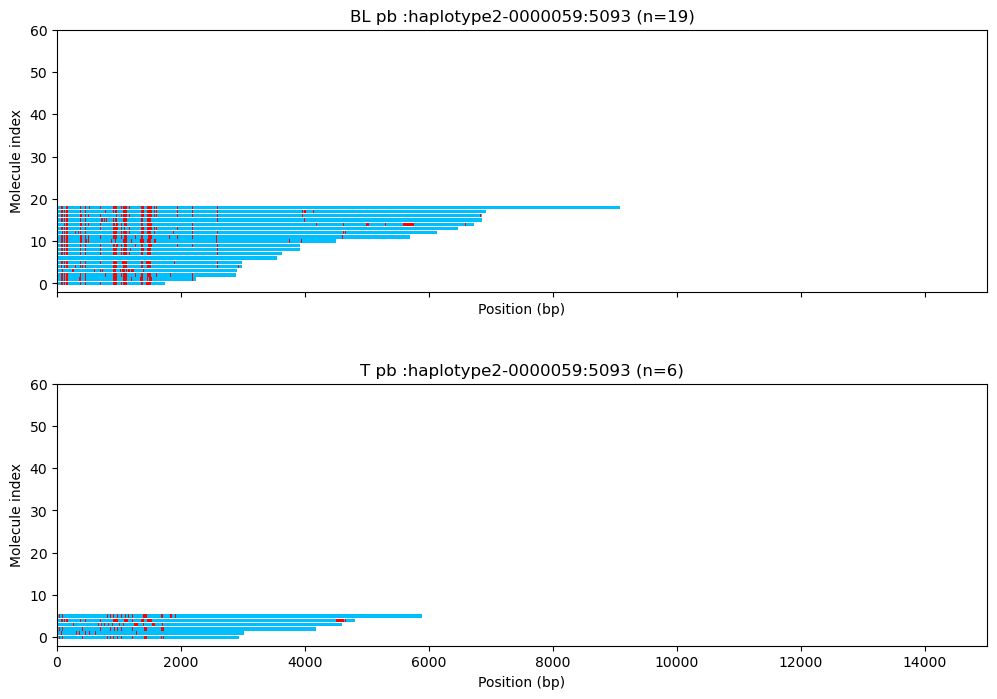

haplotype2-0000059:248309854


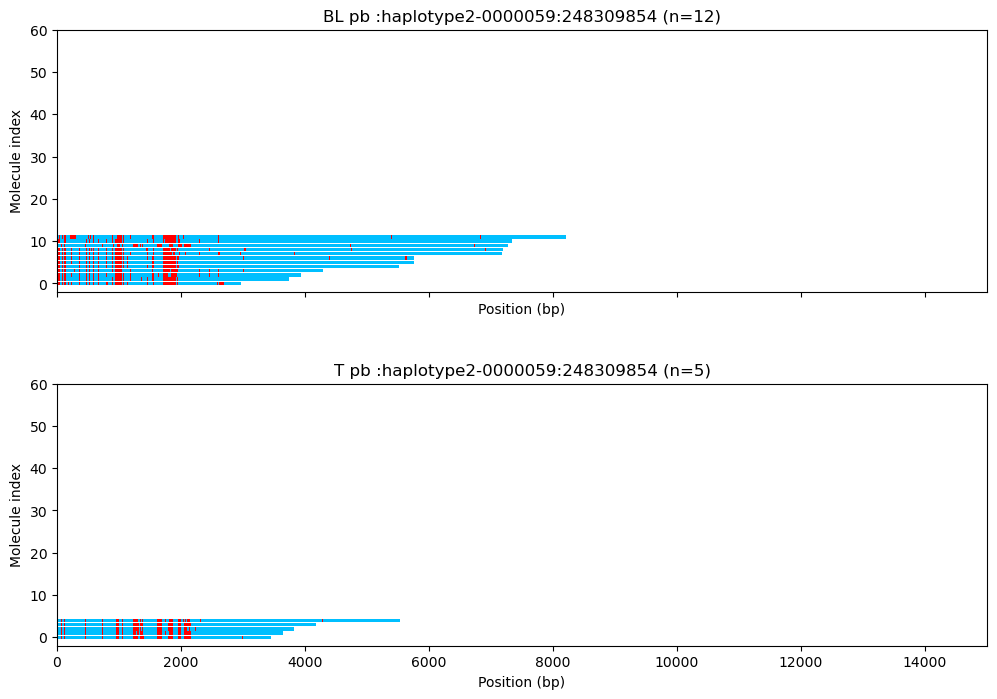

haplotype2-0000060:191276617


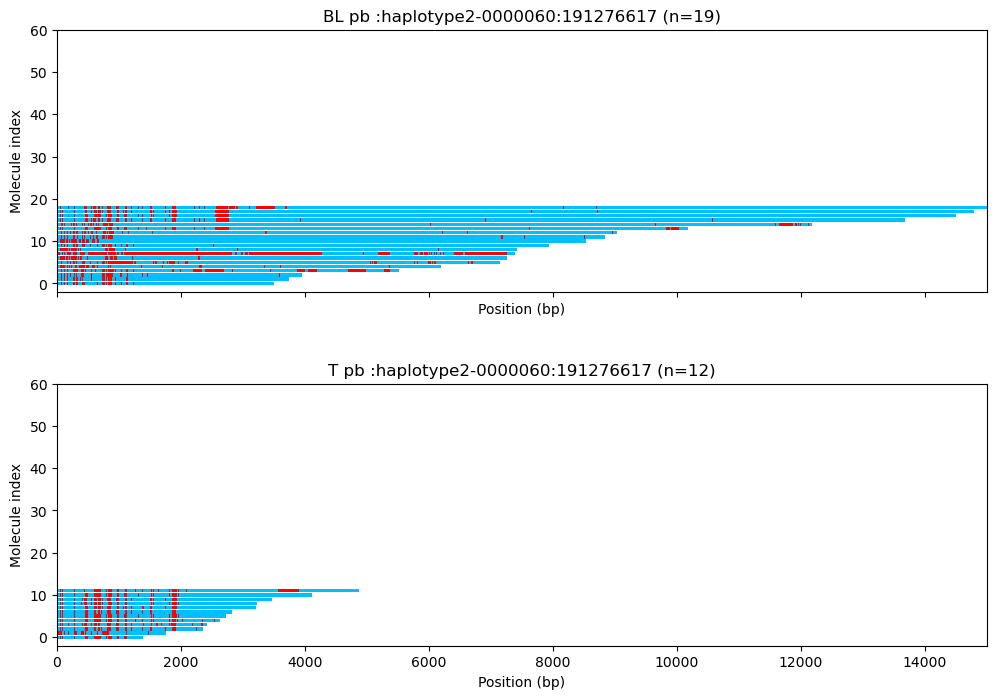

haplotype2-0000065:44892974


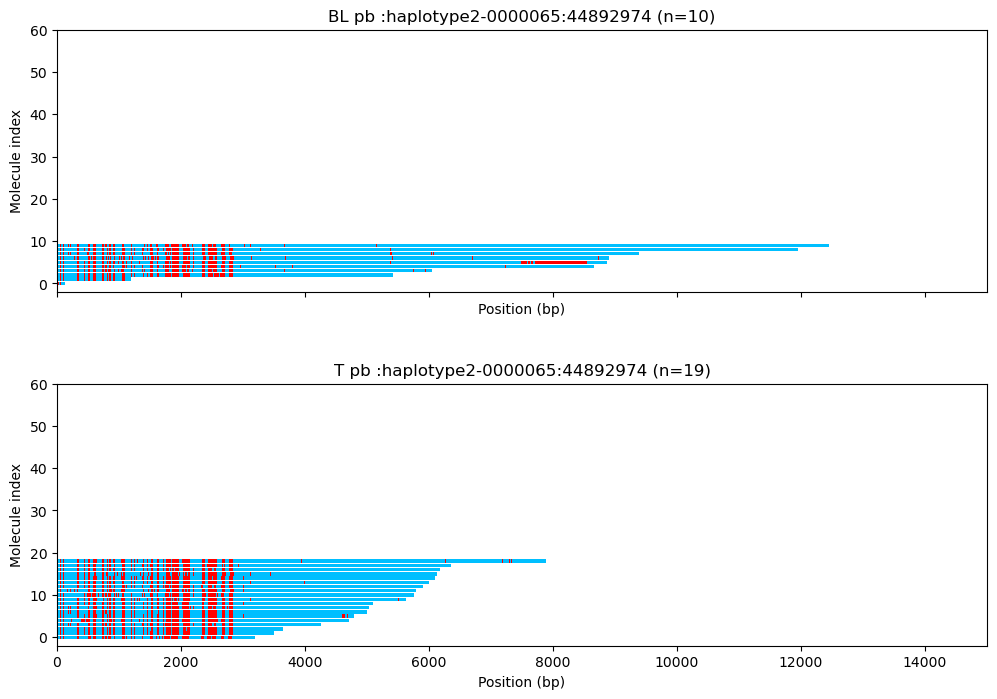

haplotype2-0000066:15367896


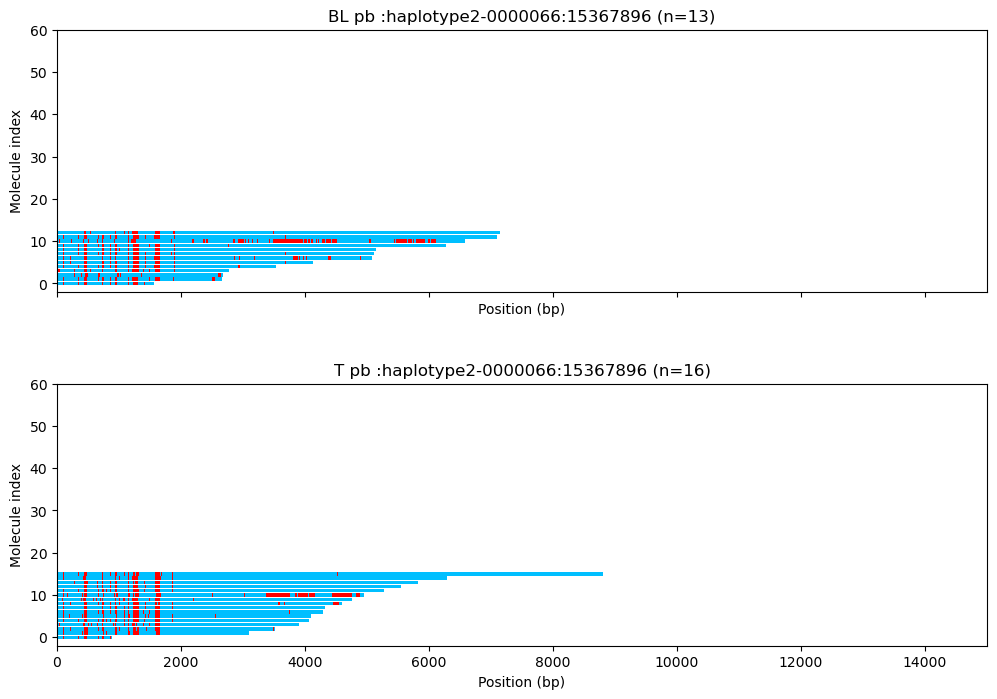

haplotype2-0000068:74068379


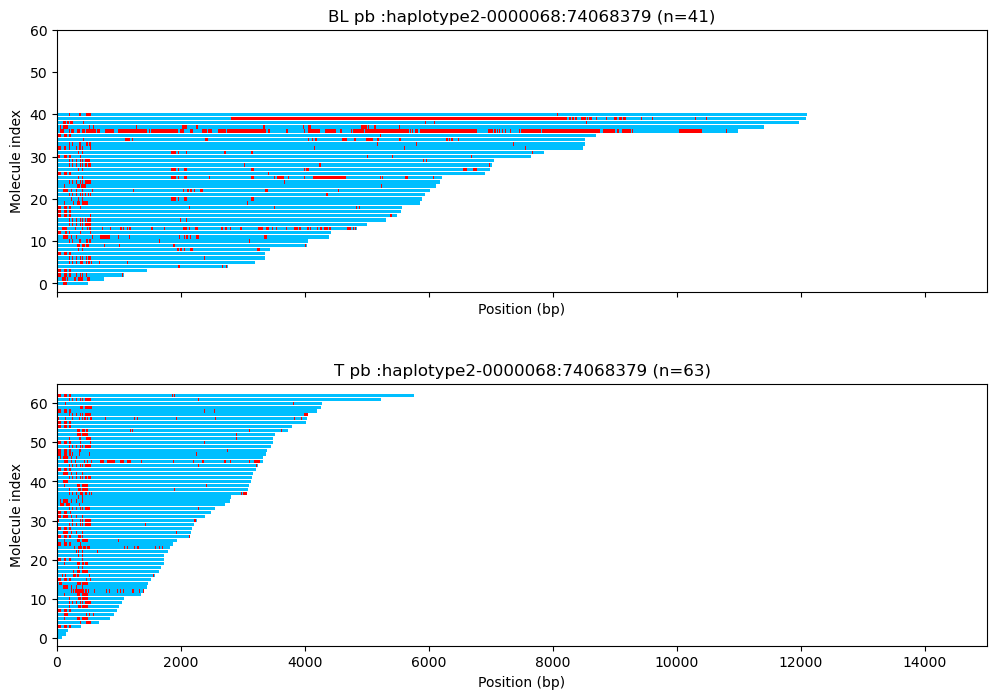

haplotype2-0000070:8002


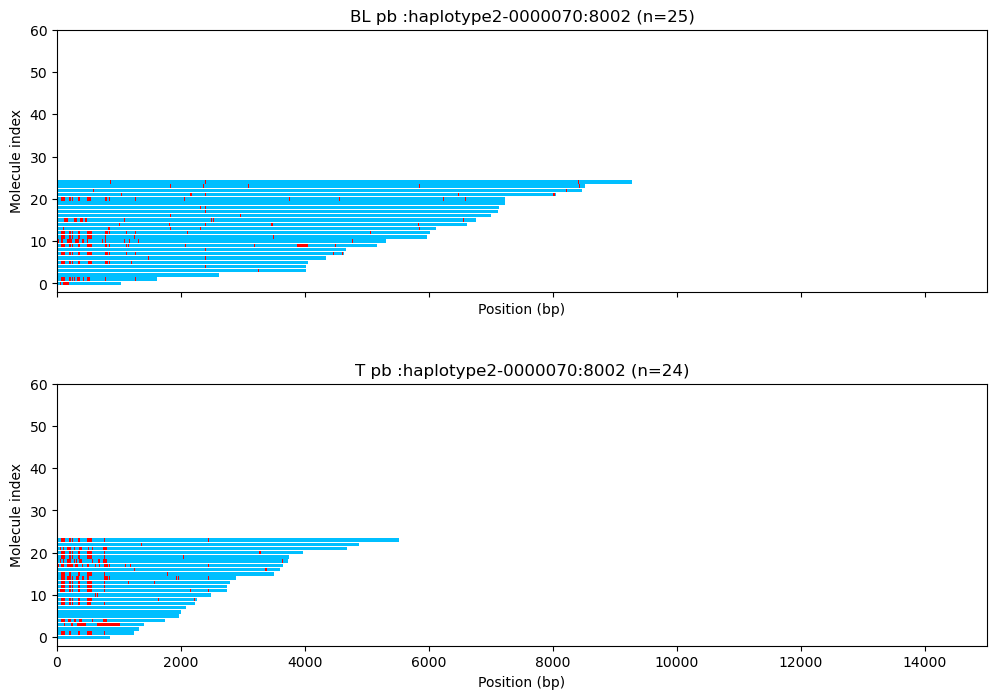

haplotype2-0000070:101206848


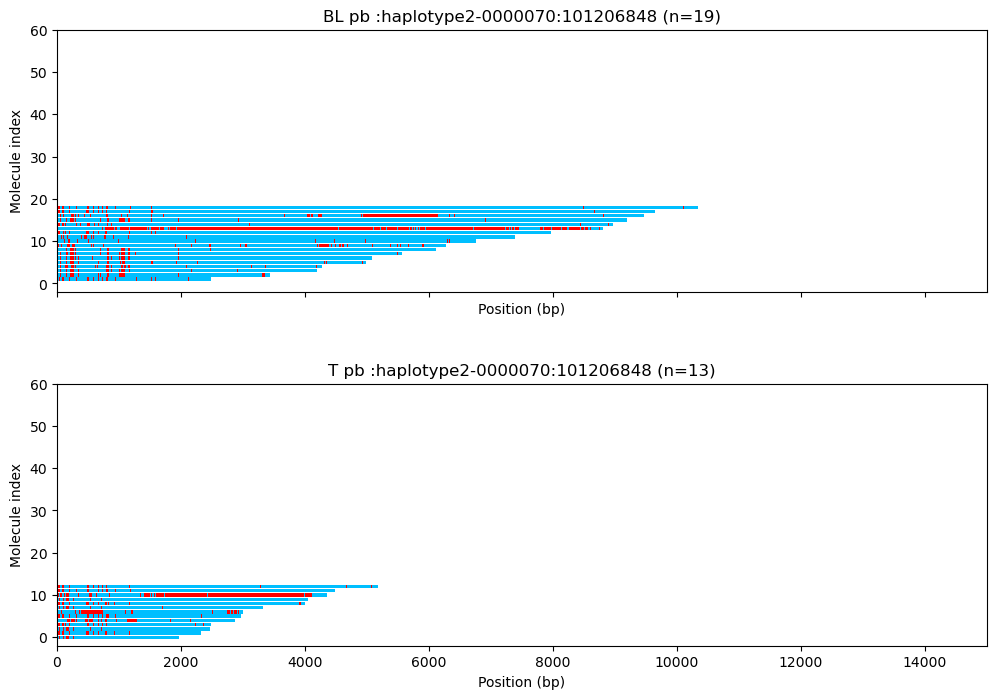

haplotype2-0000072:133720286


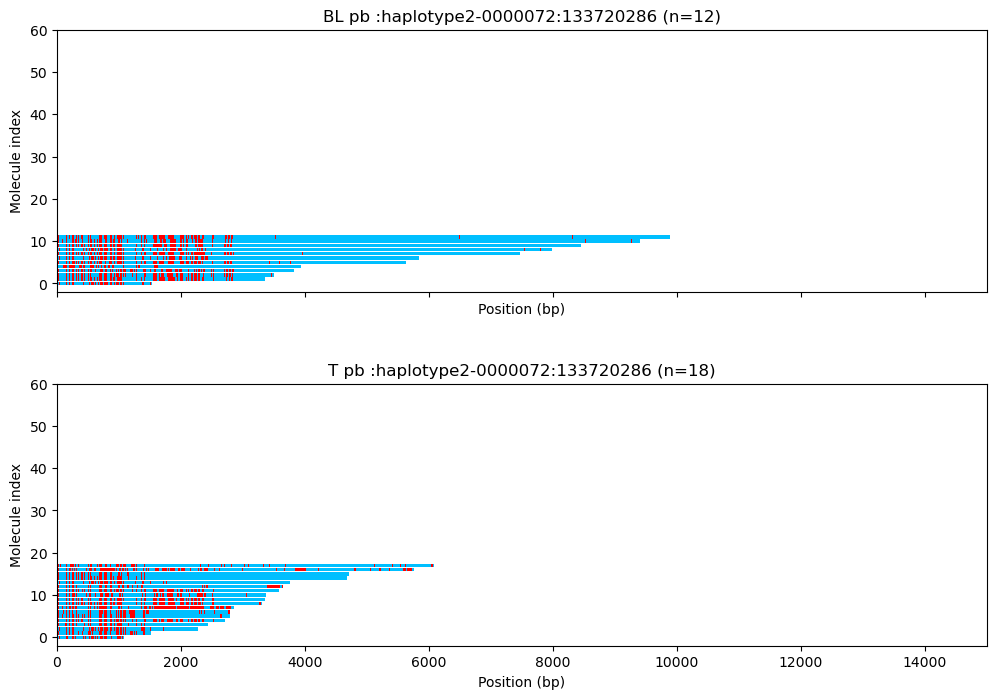

haplotype2-0000073:81490795


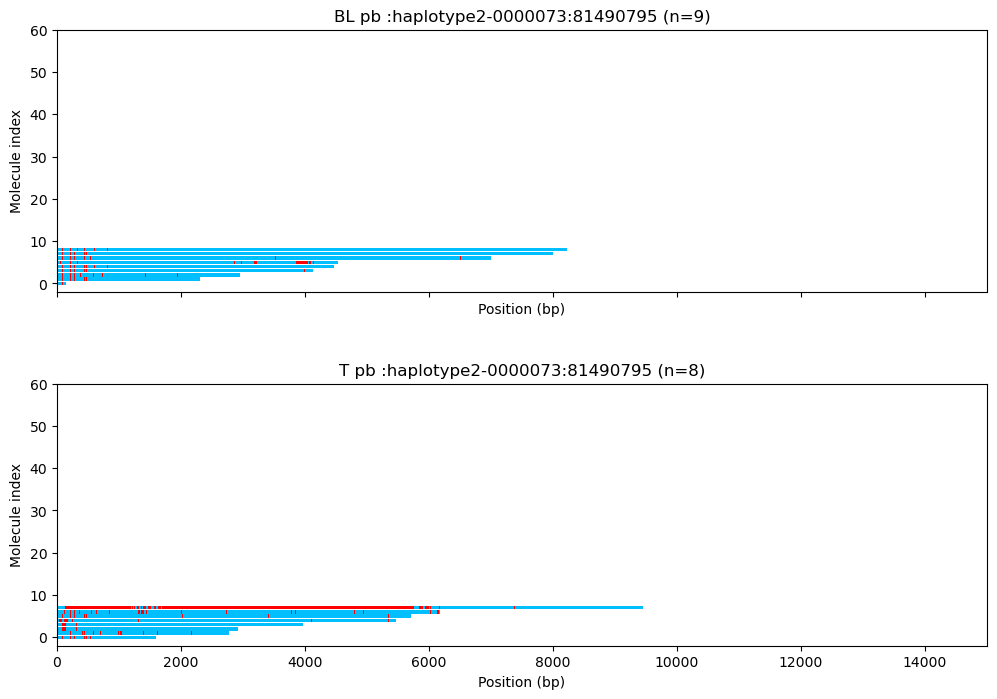

haplotype2-0000074:130138790


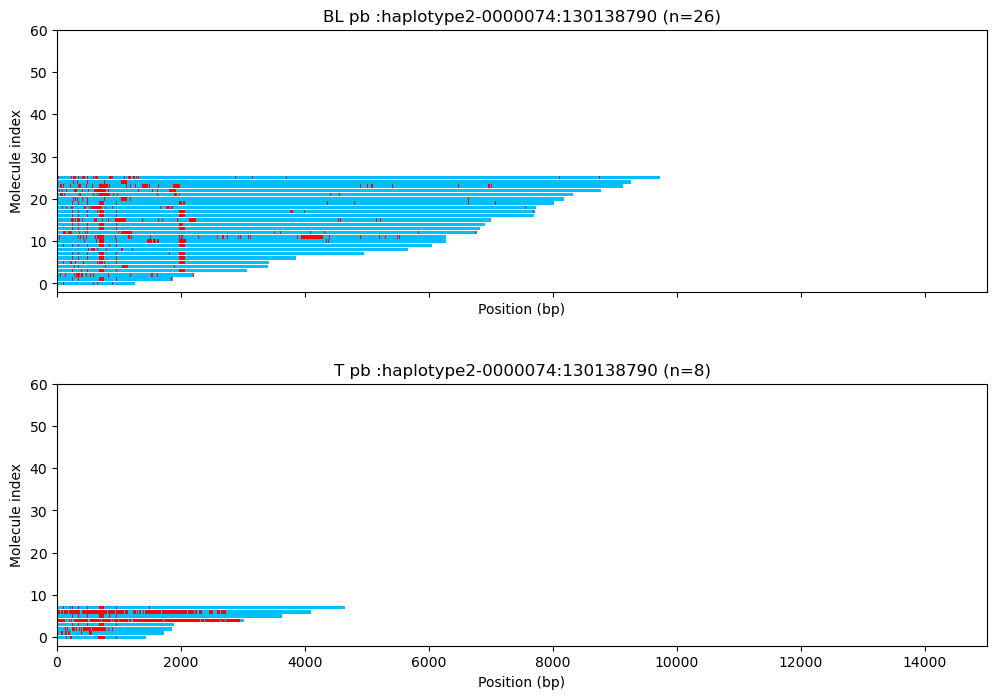

haplotype2-0000075:76179730


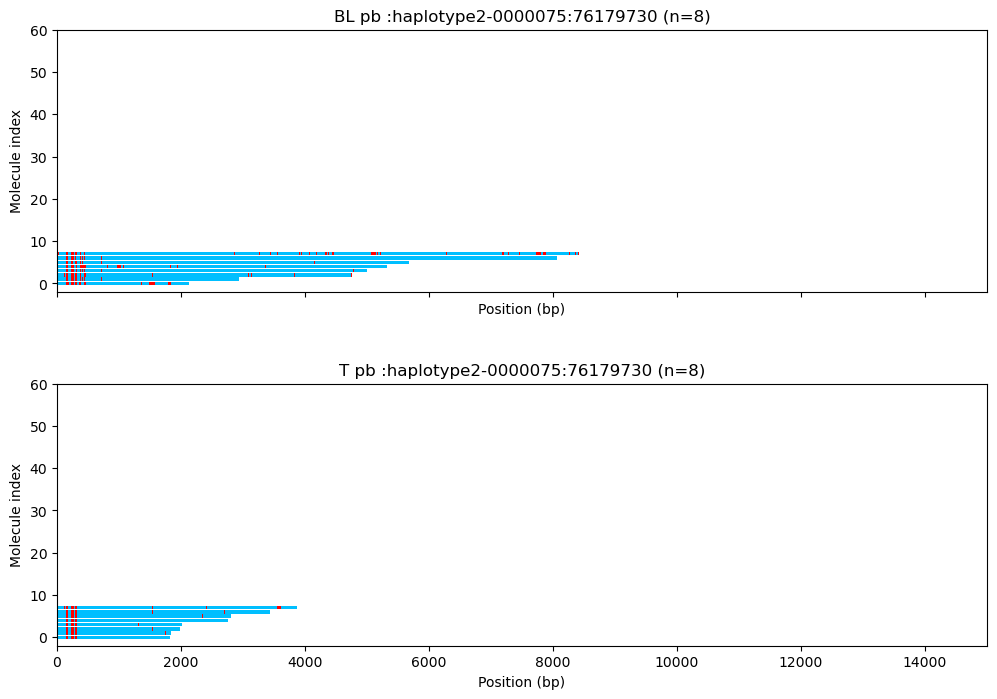

haplotype2-0000076:4577


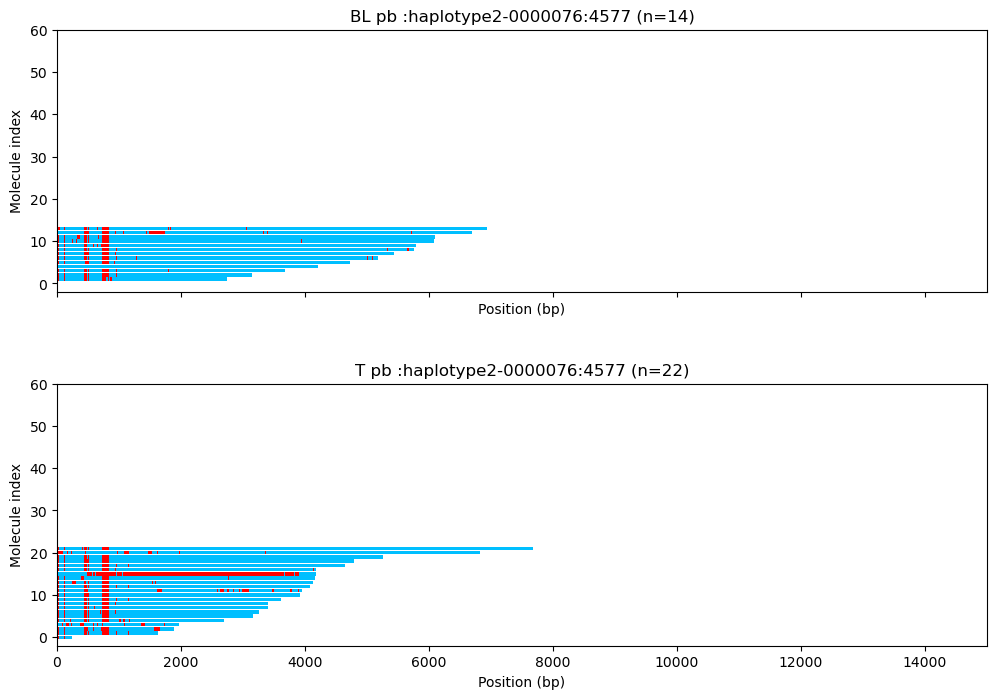

haplotype2-0000077:111684611


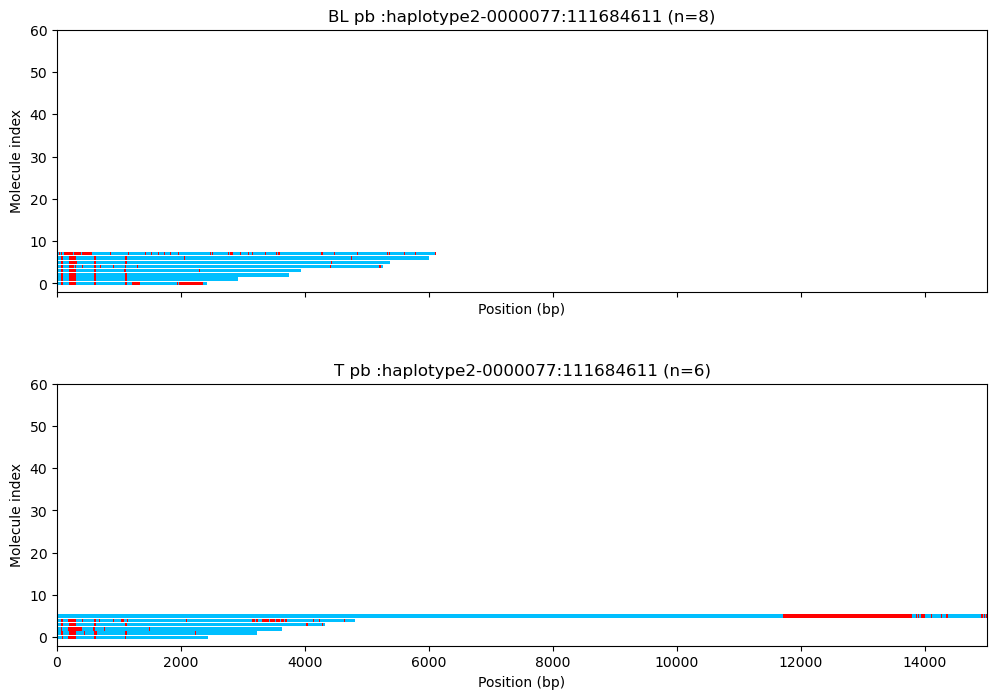

haplotype2-0000078:25176221


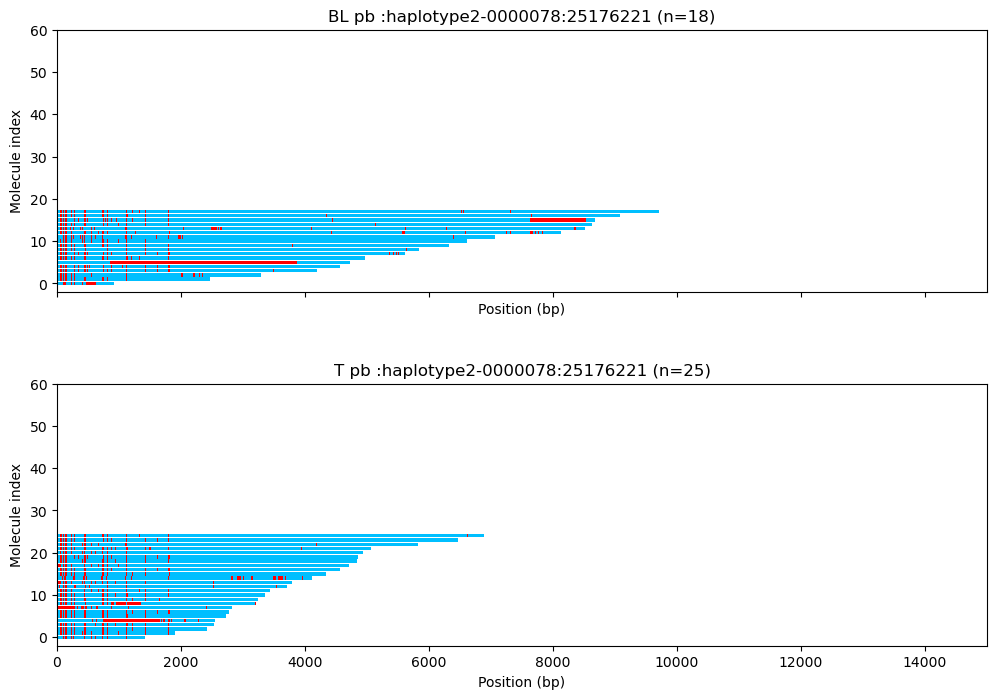

haplotype2-0000079:4288


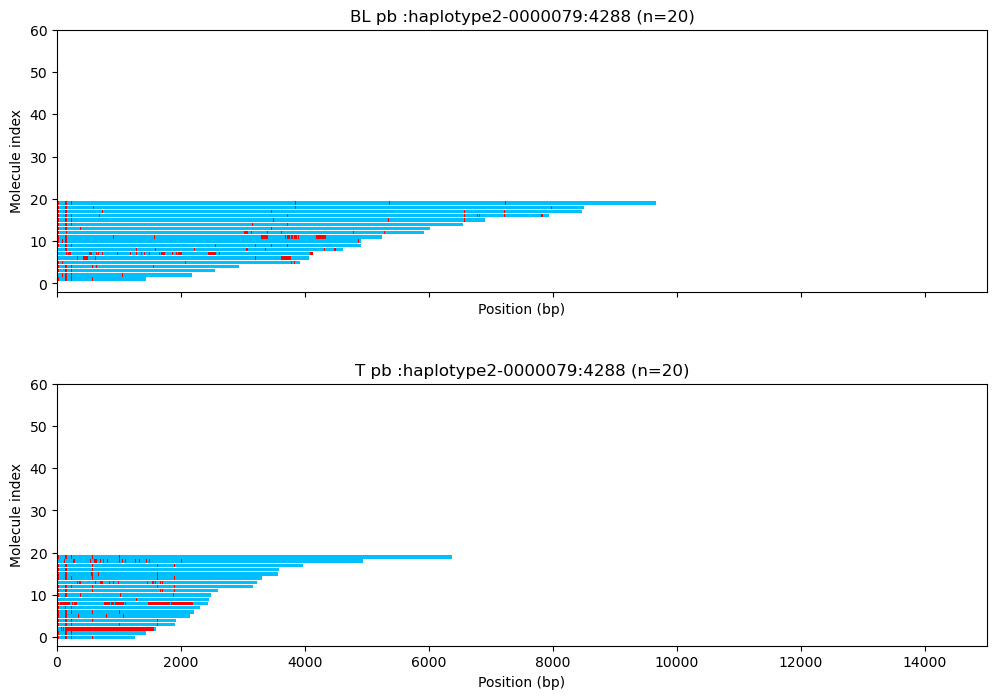

In [54]:
### PLOT ALL TELOMERE ENDS ####


all_ends = []
for end, group in all_centered_tsv['COLO829-T-PassageB_UL-ONT-R10'].groupby(['chrom','centering_position']):
    all_ends.append(end)
plots = plot_two_samples_telomeres(
    tsv1=all_centered_tsv['COLO829-BL_UL-ONT-R10'],
    tsv2=all_centered_tsv['COLO829-T-PassageB_UL-ONT-R10'],
    loci=all_ends,
    max_size=15000,
    with_m6a=False,
    pdf_path=None,  # or None to return figure handles
    title_prefix_1="BL pb :",
    title_prefix_2="T pb :",
    ylim=60,
#     shade_coords_1='dodgerblue',
#     shade_coords_2='maroon',
)

In [44]:
def bulk_noncanonical_fraction_dict(
    tsv: pd.DataFrame,
    max_size: int = 15_000,
    include_leading_trailing: bool = False,
    motif_plus: str = "ccctaa",
    motif_minus: str = "ttaggg",
    min_non_canon_size: int = 0,
    min_depth: int = 3,       
    site_min_reads: int = 3,
    trim_to_coverage: bool = True,  
):
    """
    inputs: centered telomeric reads tsv df 
    returns: per telomere end, non_canonical_sequence/depth at every position

    """
    required = {"chrom", "centering_position", "query_sequence", "centered_query_end"}
    missing = required - set(tsv.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    out = {}

    grouped = (
        tsv.assign(span=tsv.centered_query_end)
           .sort_values("span", ascending=True)
           .groupby(["chrom", "centering_position"])
    )

    for (chrom, center_pos), group in grouped:
        # site-level read threshold
        if len(group) < site_min_reads:
            continue

        depth = np.zeros(max_size, dtype=np.int32)
        noncanon = np.zeros(max_size, dtype=np.int32)
        for row in group.itertuples():
            seq = getattr(row, "query_sequence")
            qs  = int(getattr(row, "centered_query_end"))
            if not isinstance(seq, str) or qs < 1:
                continue

            subseq = seq[-qs:].lower()
            L = min(len(subseq), max_size)
            if L <= 0:
                continue

            # coverage
            depth[:L] += 1

            plus_idx  = find_substring_indices_regex(subseq, motif_plus,  invert=False)
            minus_idx = find_substring_indices_regex(subseq, motif_minus, invert=False)
            idx = plus_idx if len(plus_idx) >= len(minus_idx) else minus_idx
            idx = np.asarray(idx, dtype=int)

            if idx.size == 0:
                if include_leading_trailing:
                    noncanon[:L] += 1
                continue

            diffs = np.diff(idx)
            mask = diffs > 6
            if np.any(mask):
                starts = (idx[:-1][mask] + 6).astype(int)
                sizes  = (diffs[mask] - 6).astype(int)
                size_filter = sizes >= min_non_canon_size
                
                sizes=sizes[size_filter]
                starts=starts[size_filter]
                
                for st, sz in zip(starts, sizes):
                    if st >= L or sz <= 0:
                        continue
                    end = min(st + sz, L)
                    noncanon[st:end] += 1

            if include_leading_trailing:
                first_start = int(idx[0])
                if first_start > 0:
                    noncanon[:min(first_start, L)] += 1
                tail_start = int(idx[-1]) + 6
                if tail_start < L:
                    noncanon[tail_start:L] += 1

        valid = depth >= min_depth
        if not np.any(valid):
            continue

        if trim_to_coverage:
            last_idx = np.where(valid)[0].max() + 1  # slice end
        else:
            last_idx = max_size

        # Compute fraction only where valid; elsewhere NaN
        frac = np.full(last_idx, np.nan, dtype=float)
        d = depth[:last_idx]
        n = noncanon[:last_idx]
        mask = d >= min_depth
        frac[mask] = n[mask] / d[mask]
        out[(chrom, center_pos)] = frac

    return out

In [45]:

non_canon_signal = []
for sample in keys:
    tsv = all_centered_tsv[sample]
    non_canon_signal.append(bulk_noncanonical_fraction_dict(tsv,min_non_canon_size=0))
    

In [91]:
### SYSTEMATICALLY PICK TELOMERES WHICH HAVE UNDERGONE RESTRUCTURING 

def rolling_avg(x,N):
    return np.convolve(x, np.ones(N)/N, mode='same')

rolling_w=25
bound_cutoff = 0.3

compare_plots = {}

total_telo_compare_count = 0 
telo_w_restructure = 0 

all_ont_left = []
all_ont_right = []
all_pb_left = []
all_pb_right = []


mean_shorten_amount_ont = []
mean_shorten_amount_pb = []

mean_extension_amount_pb = []
mean_extension_amount_ont = []

keys_for_the_dots = []


# keys = [
#  'COLO829-T-PassageB_UL-ONT-R10',
#  'COLO829-BL_UL-ONT-R10',
#  'COLO829-T_pb',
#  'COLO829-BL_pb']  


for d,l in zip(non_canon_signal,labels):
    for k,v in d.items():
        if k not in compare_plots:
            compare_plots[k] = []
        compare_plots[k].append(v)

for k,v in compare_plots.items():
    if k in drop_list:
        continue

    if len(v) == 4:
        total_telo_compare_count += 1
        avg_t_ont,avg_bl_ont = rolling_avg(v[0],rolling_w),rolling_avg(v[1],rolling_w)
        avg_t_pb,avg_bl_pb = rolling_avg(v[2],rolling_w),rolling_avg(v[3],rolling_w)
        ont_idx = min([len(avg_t_ont),len(avg_bl_ont)])
        pb_idx = min([len(avg_t_pb),len(avg_bl_pb)])

        # helpers
        def first_idx_ge(arr, cutoff):
            idx = np.flatnonzero(arr >= cutoff)
            return int(idx[0]) if idx.size else None

        def last_idx_ge(arr, cutoff, end=None):
            if end is not None and end > 0:
                arr = arr[:end]
            idx = np.flatnonzero(arr >= cutoff)
            return int(idx[-1]) if idx.size else None

        # Calculate putative peaks to use to ID the point where telomere got shortened to
        # The right peak is the first peak that is present in the COLO829BL but not COLO829 
        # and the left peak is the first peaj that is present in both with 100bp buffer
        # Calculated by taking the smoothed position in the BL line and multiplying it by:
        # -(tumor - normal difference) if BL has peak and tumor doesn't we wil have a positive multiplier to
        # For the left peak its 1 - np.abs(tumor - normal differece) is they have equal occurence of TVR we get 
        # maximum val of 1 
        
        left_bounds_pb  = avg_bl_pb[:pb_idx]  * (1 - np.abs(avg_t_pb[:pb_idx]   - avg_bl_pb[:pb_idx]))
        right_bounds_pb = avg_bl_pb[:pb_idx]  * -(      avg_t_pb[:pb_idx]       - avg_bl_pb[:pb_idx])
        left_bounds_ont  = avg_bl_ont[:ont_idx] * (1 - np.abs(avg_t_ont[:ont_idx] - avg_bl_ont[:ont_idx]))
        right_bounds_ont = avg_bl_ont[:ont_idx] * -(      avg_t_ont[:ont_idx]     - avg_bl_ont[:ont_idx])

        right_most_bound_pb = first_idx_ge(right_bounds_pb, bound_cutoff)
        left_most_bound_pb  = (
            last_idx_ge(left_bounds_pb, bound_cutoff,
                        end=right_most_bound_pb if (right_most_bound_pb is not None and right_most_bound_pb > buffer) else None)
            if right_most_bound_pb is not None else None
        )

        right_most_bound_ont = first_idx_ge(right_bounds_ont, bound_cutoff)
        left_most_bound_ont  = (
            last_idx_ge(left_bounds_ont, bound_cutoff,
                        end=right_most_bound_ont if (right_most_bound_ont is not None and right_most_bound_ont > buffer) else None)
            if right_most_bound_ont is not None else None
        )

        # continue only  if both bounds exist for each platform
        span_pb  = (left_most_bound_pb is not None)  and (right_most_bound_pb is not None)
        span_ont = (left_most_bound_ont is not None) and (right_most_bound_ont is not None)

        if span_pb and span_ont:
            all_pb_left.append(left_most_bound_pb)
            all_pb_right.append(right_most_bound_pb)

            all_ont_left.append(left_most_bound_ont)
            all_ont_right.append(right_most_bound_ont)

     
        # only count if at both platform has a valid span
        span = span_pb and span_ont
        if span:
            print(k)
            keys_for_the_dots.append(k)
            telo_w_restructure += 1


('haplotype1-0000002', 3070)
('haplotype1-0000004', 6362)
('haplotype1-0000005', 44327944)
('haplotype1-0000007', 3999)
('haplotype1-0000014', 4366)
('haplotype1-0000021', 133807714)
('haplotype1-0000026', 172187974)
('haplotype2-0000048', 84346615)
('haplotype2-0000054', 3999)
('haplotype2-0000055', 8877)
('haplotype2-0000060', 191276617)
('haplotype2-0000075', 76179730)


/var/folders/_g/p69fnyf973l44t6hp4m04mdw0000gn/T/ipykernel_5681/2017836601.py:43: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if k in drop_list:


In [95]:
# systematically ID'd telo ends
print(f' % telos restructured ont and pacbio : {telo_w_restructure/total_telo_compare_count}')

# systematically ID'd telos that were then confirmed by eye
filtered_ends =  [
                 ['haplotype1-0000002', '3070'],
                 ['haplotype1-0000004', '6362'],
                 ['haplotype1-0000005', '44327944'],
                 ['haplotype1-0000007', '3999'],
                 ['haplotype1-0000014', '4366'],
                 ['haplotype1-0000021', '133807714'],
                 ['haplotype1-0000026', '172187974'],
                 ['haplotype2-0000048', '84346615'],
                 ['haplotype2-0000055', '8877'],
                 ['haplotype2-0000075', '76179730']
                 ]

print(f' % telos restructured ont and pacbio : {len(filtered_ends)/total_telo_compare_count}')


 % telos restructured ont and pacbio : 0.1875
 % telos restructured ont and pacbio : 0.15625


haplotype1-0000002:3070


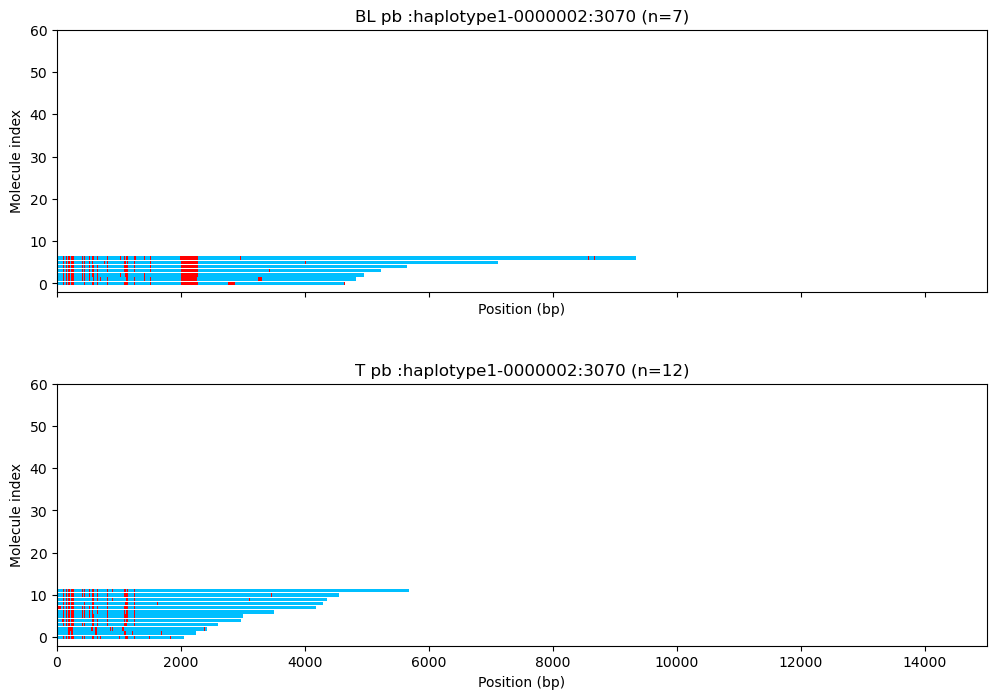

haplotype1-0000004:6362


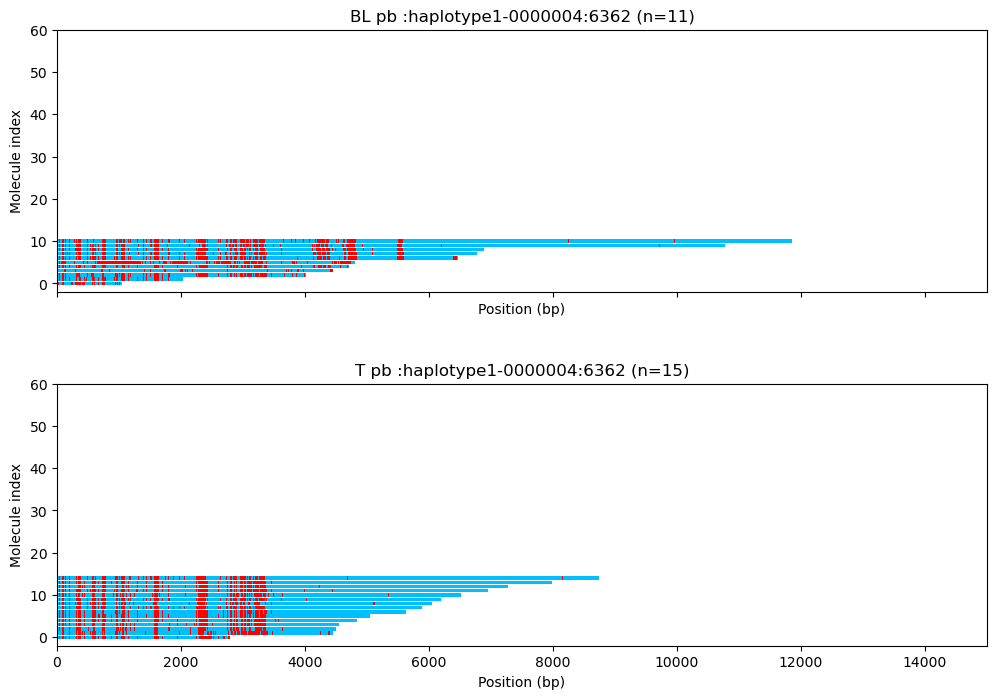

haplotype1-0000005:44327944


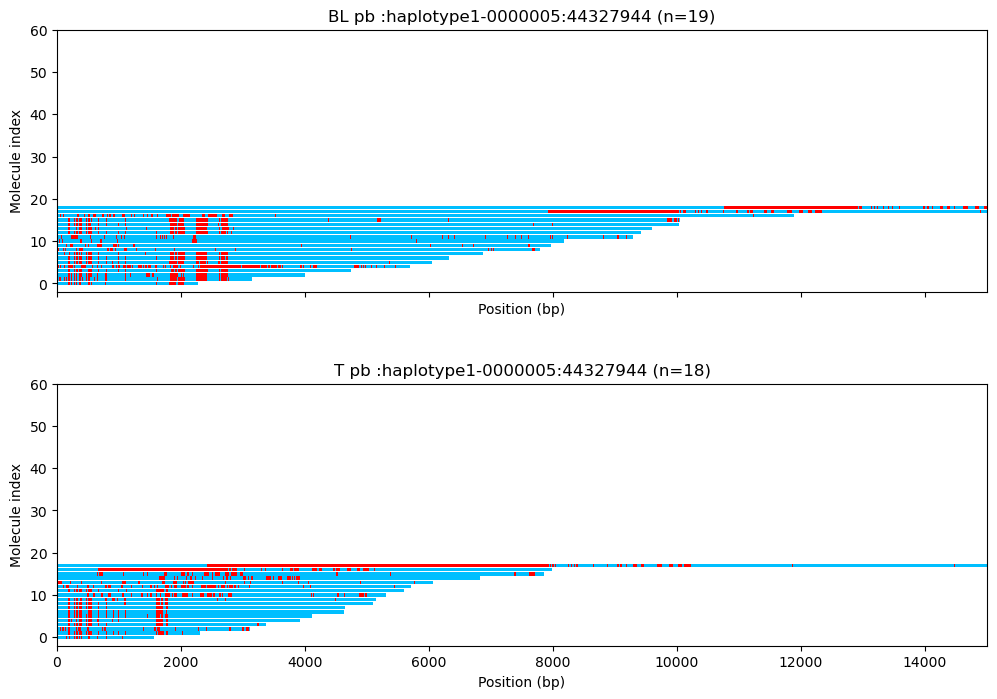

haplotype1-0000007:3999


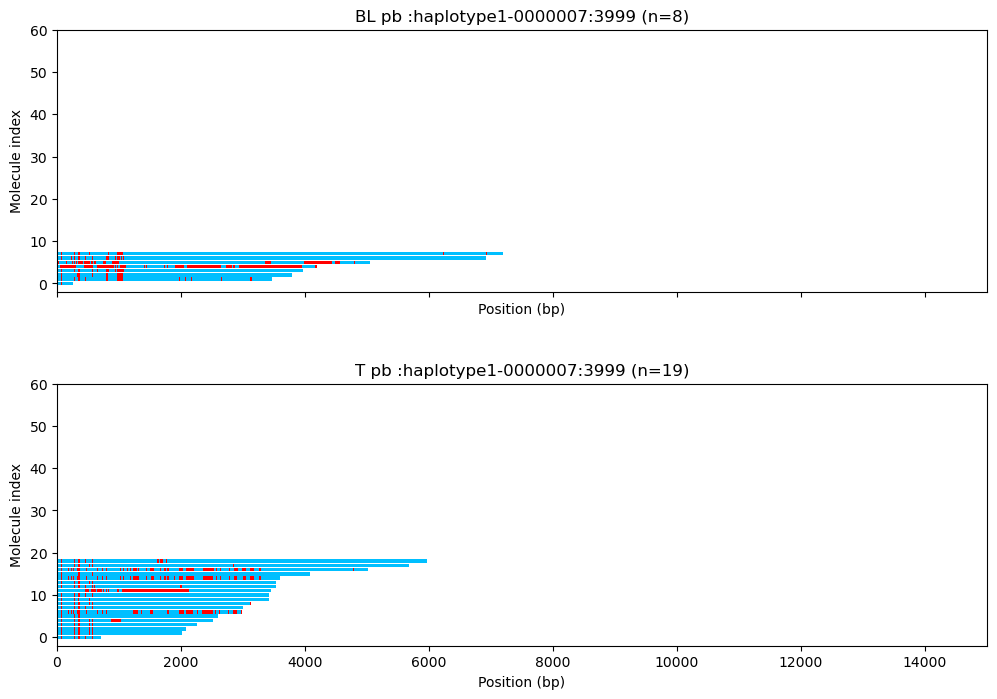

haplotype1-0000014:4366


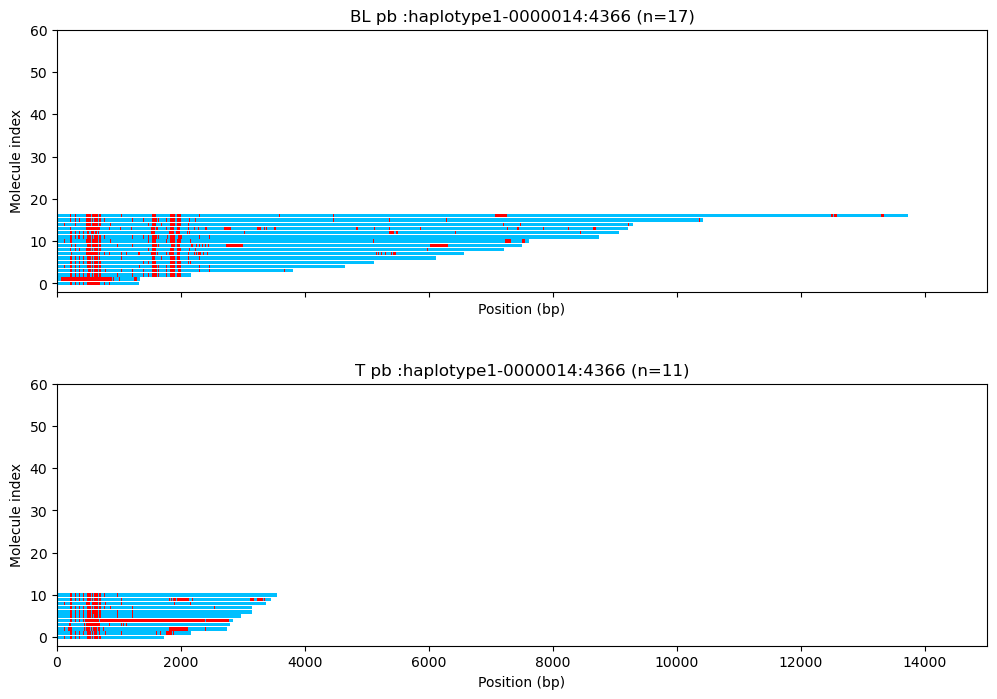

haplotype1-0000021:133807714


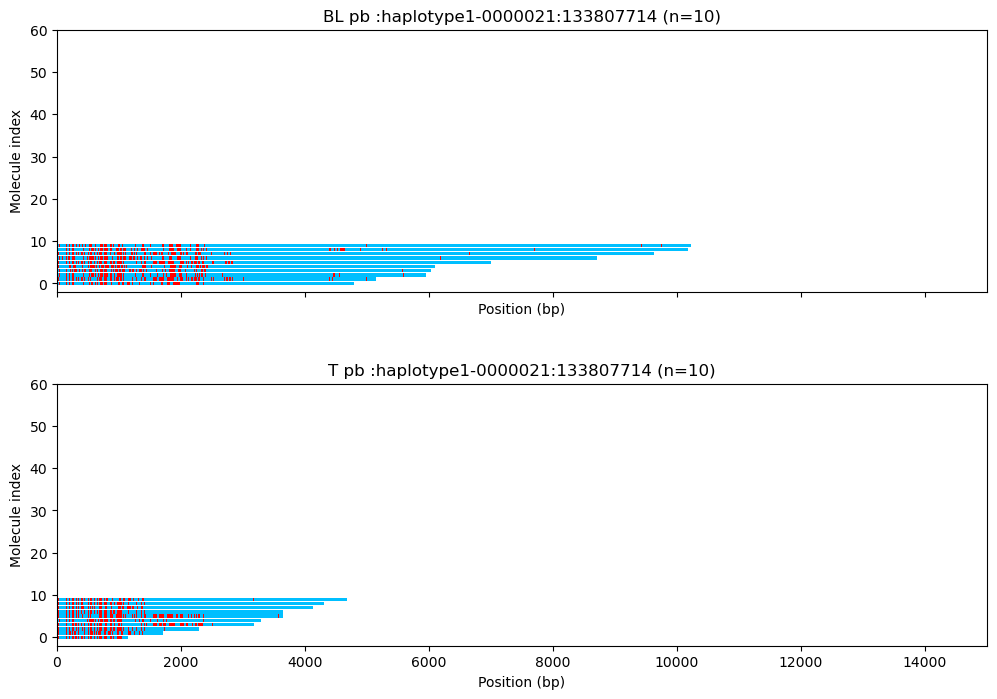

haplotype1-0000026:172187974


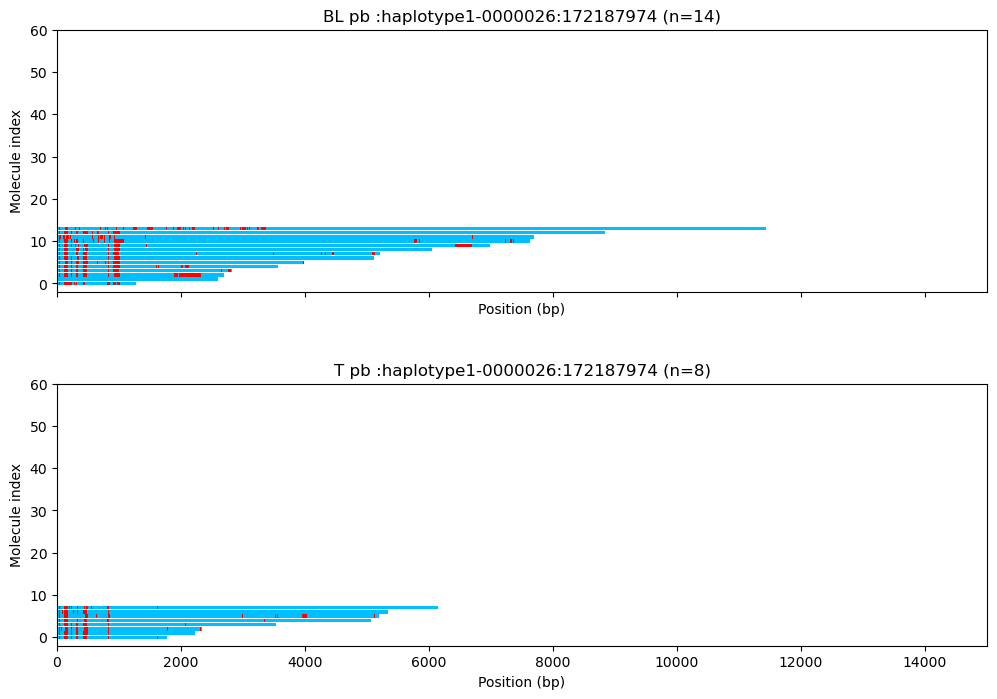

haplotype2-0000048:84346615


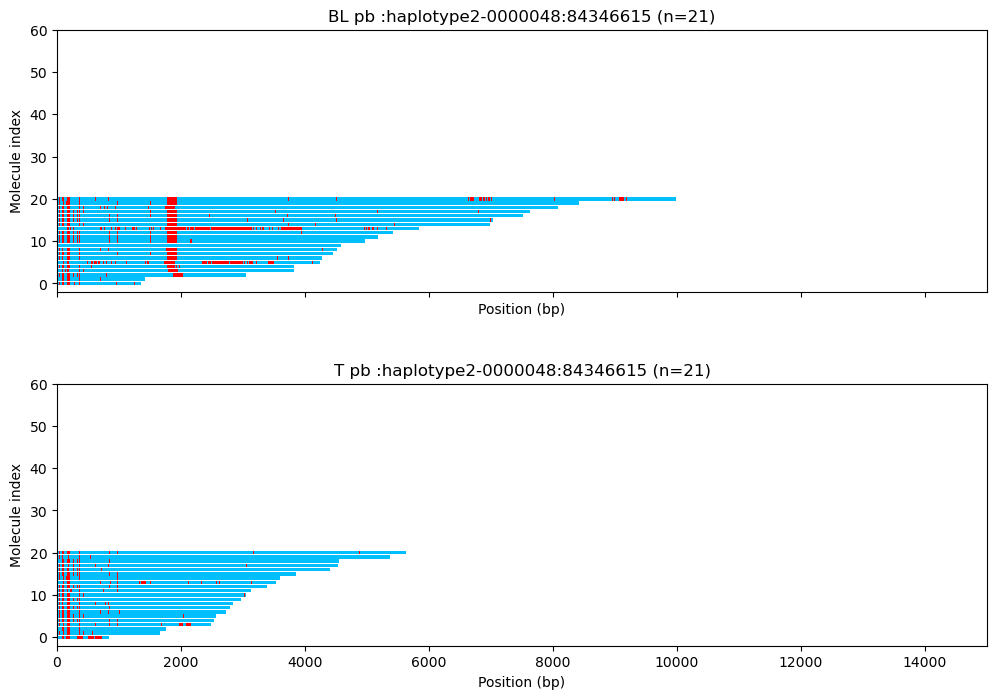

haplotype2-0000055:8877


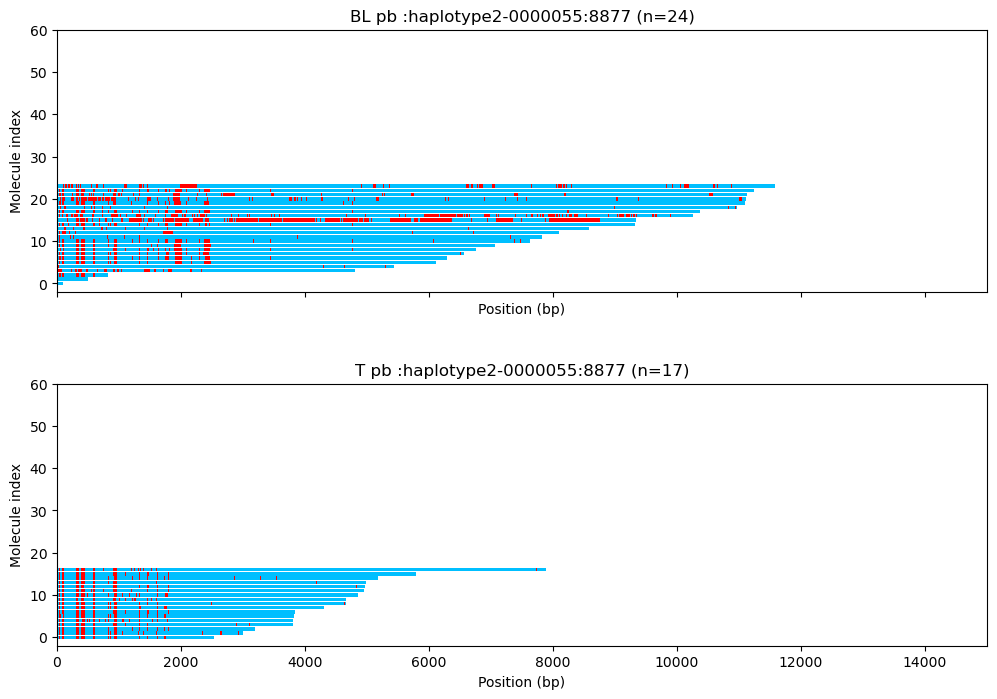

haplotype2-0000075:76179730


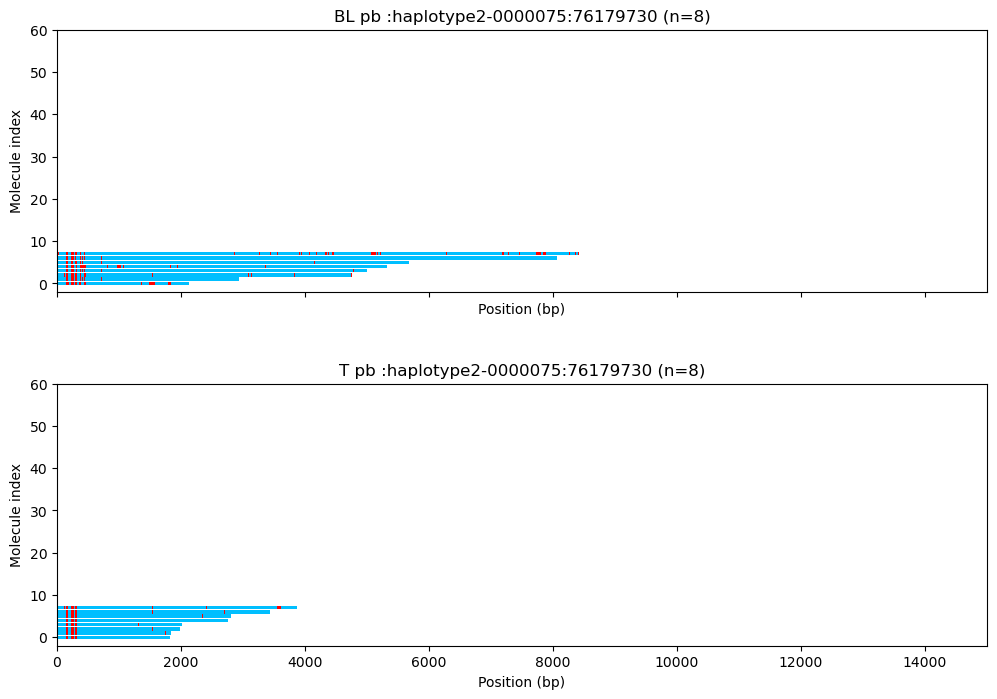

In [96]:


# Plot ONT-R10 of filtered telos 
plots = plot_two_samples_telomeres(
    tsv1=all_centered_tsv['COLO829-BL_UL-ONT-R10'],
    tsv2=all_centered_tsv['COLO829-T-PassageB_UL-ONT-R10'],
    loci=filtered_ends,
    max_size=15000,
    with_m6a=False,
    pdf_path=None,  # or None to return figure handles
    title_prefix_1="BL pb :",
    title_prefix_2="T pb :",
    ylim=60,
    shade_coords_1='dodgerblue',
    shade_coords_2='maroon')